# Goal:

We have by now studied a lot that the algorithm is able to reconstruct the target gate set with both the least squares and the log-likelihood cost functions. Now, our objective is to have a way of numerically obtaining a metric for how many numbers of sequences are needed to achieve a successful reconstruction

From Raphael's paper, this might look like a phase transition in the MVE evaluated at random sequences using the reconstructed gate set vs the number of sequences used in the experiment.

By starting with very low number of sequences and increasing them, hopefully we are able to see something like this here as well! 🤞

Date of creation: 23.07.2026

In [131]:
from iqm.benchmarks.compressive_gst.compressive_gst import GSTConfiguration
from mGST.utility_functions_comparisons import all_operators_from_configuration, get_compressed_rep_from_mgst_output, kraus_tensor_to_mgst, get_compressed_perturbed_kraus_from_superop, get_compressed_perturbed_rep_from_mgst
from mGST.simulate import get_random_noisy_kraus_tensors_for_gate_set, apply_noisy_kraus_tensors_to_target_gate_set, run_optimization_workflow
from mGST.low_level_jit import process_fidelity
from mGST.typing import OperatorSchedule, TrustRegionOptions
from mGST.visualization import plot_cost_function, plot_mean_std_vs_x
from mGST.analysis import variational_error_avg_and_std_from_list_of_superops, compute_diamond_distances_from_list_of_superops

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Create noiseless and noisy tensors

In [23]:
num_sequences = 100
num_shots = 1000
seq_len_list = [1, 8, 14]
num_qubits = 1
dim = 2 ** num_qubits
state_rank = dim # max
povm_rank = dim # max
kraus_rank = dim**2
num_gates = 3
num_povm = dim
backend = "iqmfakeapollo"

In [19]:
configuration = GSTConfiguration(
    qubit_layouts=[[0]],
    gate_set="1QXYI",
    num_circuits=num_sequences,
    shots=num_shots,
    rank=1,
)

target_operators, gate_labels = all_operators_from_configuration(configuration, backend)
print(target_operators.keys())
print([op.shape for op in target_operators.values()])

dict_keys(['kraus', 'povm', 'state'])
[(3, 1, 2, 2), (2, 4), (4,)]


In [48]:
# Create the random kraus tensors that will be applied to the target gate set.
noise_strength = 5e-3
random_kraus_tensors = get_random_noisy_kraus_tensors_for_gate_set(
    num_gates=num_gates,
    dim=dim,
    rank_kraus=kraus_rank,
    noise_strength=noise_strength,
    seed=42
)
[op.shape for op in random_kraus_tensors.values()]

[(3, 4, 2, 2), (4, 2, 2), (4, 2, 2)]

In [49]:
target_operators_unvect = target_operators.copy()
target_operators_unvect["povm"] = target_operators_unvect["povm"].reshape(dim, dim, dim)
target_operators_unvect["state"] = target_operators_unvect["state"].reshape(dim, dim)

In [50]:
noisy_gate_set_superop = apply_noisy_kraus_tensors_to_target_gate_set(
    kraus_tensors_noisy=random_kraus_tensors,
    target_gate_set=target_operators_unvect,
)
print([f"{name}: {op.shape}" for name, op in noisy_gate_set_superop.items()])

kraus_tensor_noisy, povm_psd_noisy, state_psd_noisy = get_compressed_rep_from_mgst_output(*noisy_gate_set_superop.values(), kraus_rank=kraus_rank, state_rank=state_rank, povm_rank=povm_rank)

['kraus: (3, 4, 4)', 'povm: (2, 4)', 'state: (4,)']


In [51]:
# let's get the remaining PSD representations
kraus_target_superop = kraus_tensor_to_mgst(target_operators["kraus"])
# 1. Target
target_gate_set_superops = {
    "kraus": kraus_target_superop,
    "povm": target_operators["povm"],
    "state": target_operators["state"],
}

kraus_tensor_target, povm_psd_target, state_psd_target = get_compressed_rep_from_mgst_output(*target_gate_set_superops.values(), kraus_rank=kraus_rank, state_rank=state_rank, povm_rank=povm_rank)

# 2. Initiallization
kraus_tensor_init_dict = get_compressed_perturbed_kraus_from_superop(superop=kraus_target_superop, rank=kraus_rank, seed=42)
kraus_tensor_init = kraus_tensor_init_dict["kraus_tensor"]

povm_psd_init, state_psd_init = get_compressed_perturbed_rep_from_mgst(target_operators["povm"], target_operators["state"], rank_povm=povm_rank, rank_state=state_rank)

# Gathering them all in one place
target_gate_set_psd = {
    "kraus": kraus_tensor_target,
    "povm": povm_psd_target,
    "state": state_psd_target,
}

noisy_gate_set_psd = {
    "kraus": kraus_tensor_noisy,
    "povm": povm_psd_noisy,
    "state": state_psd_noisy,
}

init_gate_set_psd = {
    "kraus": kraus_tensor_init,
    "povm": povm_psd_init,
    "state": state_psd_init,
}

In [72]:
# just a quick test of what is the frobenius norm between the noisy and the target ones.
fidelity_kraus_target_vs_noisy = process_fidelity(kraus_tensor_est=kraus_tensor_noisy, kraus_tensor_target=kraus_tensor_target, unitary=True)
print(f"Fidelity between target and noisy Kraus tensors: {fidelity_kraus_target_vs_noisy}")

fidelity_kraus_init_vs_target = process_fidelity(kraus_tensor_est=kraus_tensor_init, kraus_tensor_target=kraus_tensor_target, unitary=True)
print(f"Fidelity between target and initial Kraus tensors: {fidelity_kraus_init_vs_target}") # closer than the other since we start close to the target.

fidelity_kraus_init_vs_noisy = process_fidelity(kraus_tensor_est=kraus_tensor_init, kraus_tensor_target=kraus_tensor_noisy, unitary=True)
print(f"Fidelity between noisy and initial Kraus tensors: {fidelity_kraus_init_vs_noisy}")

Fidelity between target and noisy Kraus tensors: 2.999987679080297
Fidelity between target and initial Kraus tensors: 2.9951011636606752
Fidelity between noisy and initial Kraus tensors: 2.9951561294286773


# Optimization

In [59]:
num_iterations_outer = 20
num_iterations_tr = 5
num_iterations_cg = 10 
tol_grad = 1e-8 # it was 1e-4 before. 1e-8 is suggested in the book.

tr_schedule_verbose = OperatorSchedule.default(num_iterations_outer, TrustRegionOptions(num_iterations=num_iterations_tr, verbose=True, verbose_cg=False, num_iterations_cg=num_iterations_cg, tol_grad=tol_grad))

relative_precision = 1e-11 # decrease by 2 orders of magnitude.
global_grad_norm_tol = 1e-10 #

optimization_schedule_all_tr = {
    "kraus": tr_schedule_verbose,
    "povm": tr_schedule_verbose,
    "state": tr_schedule_verbose
}

optimization_options = {
    "schedule": optimization_schedule_all_tr,
    "num_iterations_outer": num_iterations_outer,
    "relative_precision": relative_precision,
    "global_gradient_norm_tol": global_grad_norm_tol
}
optimization_options

{'schedule': {'kraus': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))]),
  'povm': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))]),
  'state': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))])},
 'num_iterations_outer': 20,
 'relative_precision': 1e-11,
 'global_gradient_norm_tol': 1e-10}

## Exact shots

In [69]:
optimization_results_100_seq_exact = run_optimization_workflow(
    num_sequences=100,
    num_shots=1,
    init_operators=init_gate_set_psd,
    operators_psd_true=noisy_gate_set_psd,
    target_superops=target_gate_set_superops,
    use_exact_probabilities=True,
    optimization_options=optimization_options,
    warmup_run=True,
    use_log_likelihood=True,
    compute_least_squares=1, # to compute after every operator
)

Using exact probabilities 🔪
Using log-likelihood for the cost function optimization 🧮
🏎️ Warming up the cost function ...
Initial cost value: 46.237391965377235
⚠️ Computing least squares values during optimization. This may add additional computational overhead. ⚠️
🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-19]: TrustRegionOptions
povm: Schedule:
  [0-19]: TrustRegionOptions
state: Schedule:
  [0-19]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-11 
+ Gradient(s) Norm(s) 📐
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 4.623739e+01. |r∇f(x)|: 1.252748e+02. Radius: 1.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/simulate.py:460: UserWarning: Setting num_shots=1 when using exact probs.
  "indices_list": indices_list,


Update rejected ❌.
TR Iteration: 1. f(x): 4.623739e+01. |r∇f(x)|: 1.252748e+02. Radius: 2.50e-02
Update rejected ❌.
TR Iteration: 2. f(x): 4.623739e+01. |r∇f(x)|: 1.252748e+02. Radius: 6.25e-03
Update rejected ❌.
TR Iteration: 3. f(x): 4.623739e+01. |r∇f(x)|: 1.252748e+02. Radius: 1.56e-03
Update rejected ❌.
TR Iteration: 4. f(x): 4.623739e+01. |r∇f(x)|: 1.252748e+02. Radius: 3.91e-04
Update rejected ❌.
Optimization finished ✅. 
 Iters: 5. f(x): 4.623739e+01. |r∇f(x)|: 1.252748e+02. Radius: 9.77e-05. Rejections: 5
at iteration 0 the new count changed to: 16
at iteration 1 the new count changed to: 17
at iteration 4 the new count changed to: 18
at iteration 10 the new count changed to: 19
at iteration 16 the new count changed to: 20
at iteration 22 the new count changed to: 21
at iteration 29 the new count changed to: 22
at iteration 36 the new count changed to: 23
at iteration 43 the new count changed to: 24
at iteration 50 the new count changed to: 25
at iteration 58 the new count cha

In [76]:
optimization_results_100_seq_1000_shots = run_optimization_workflow(
    num_sequences=100,
    num_shots=num_shots,
    init_operators=init_gate_set_psd,
    operators_psd_true=noisy_gate_set_psd,
    target_superops=target_gate_set_superops,
    use_exact_probabilities=False,
    optimization_options=optimization_options,
    warmup_run=False,
    use_log_likelihood=True,
    compute_least_squares=1, # to compute after every operator
)

Using log-likelihood for the cost function optimization 🧮
⚠️ Computing least squares values during optimization. This may add additional computational overhead. ⚠️
🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-19]: TrustRegionOptions
povm: Schedule:
  [0-19]: TrustRegionOptions
state: Schedule:
  [0-19]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-11 
+ Gradient(s) Norm(s) 📐
at iteration 0 the new count changed to: 31
at iteration 1 the new count changed to: 32
at iteration 4 the new count changed to: 33
at iteration 10 the new count changed to: 34
at iteration 16 the new count changed to: 35
at iteration 22 the new count changed to: 36
at iteration 29 the new count changed to: 37
at iteration 36 the new count changed to: 38
at iteration 43 the new count changed to: 39
at iteration 50 the new count changed to: 40
at iteration 58 the new count changed to: 41
at iteration 66 the new count changed to: 42
at iteration 7

# Analysis

In [96]:
title_100_seq = rf"{num_qubits}Q | only Kraus perturbed | $r_\mathrm{{Kraus}}$: {kraus_rank} | $r_\mathrm{{POVM}}$: {povm_rank} | $r_\mathrm{{State}}$: {state_rank} | Random Noisy Gate Set |" + "\n" + f"Num sequences: {num_sequences}"

optimization_results_list = [optimization_results_100_seq_exact, optimization_results_100_seq_1000_shots]

times = [results["times"]["optimization_time"] for results in optimization_results_list]

labels = [rf"shots: $\infty$ | time: {times[0]:.2f} s", rf"shots: $1000$ | time: {times[1]:.2f} s"]


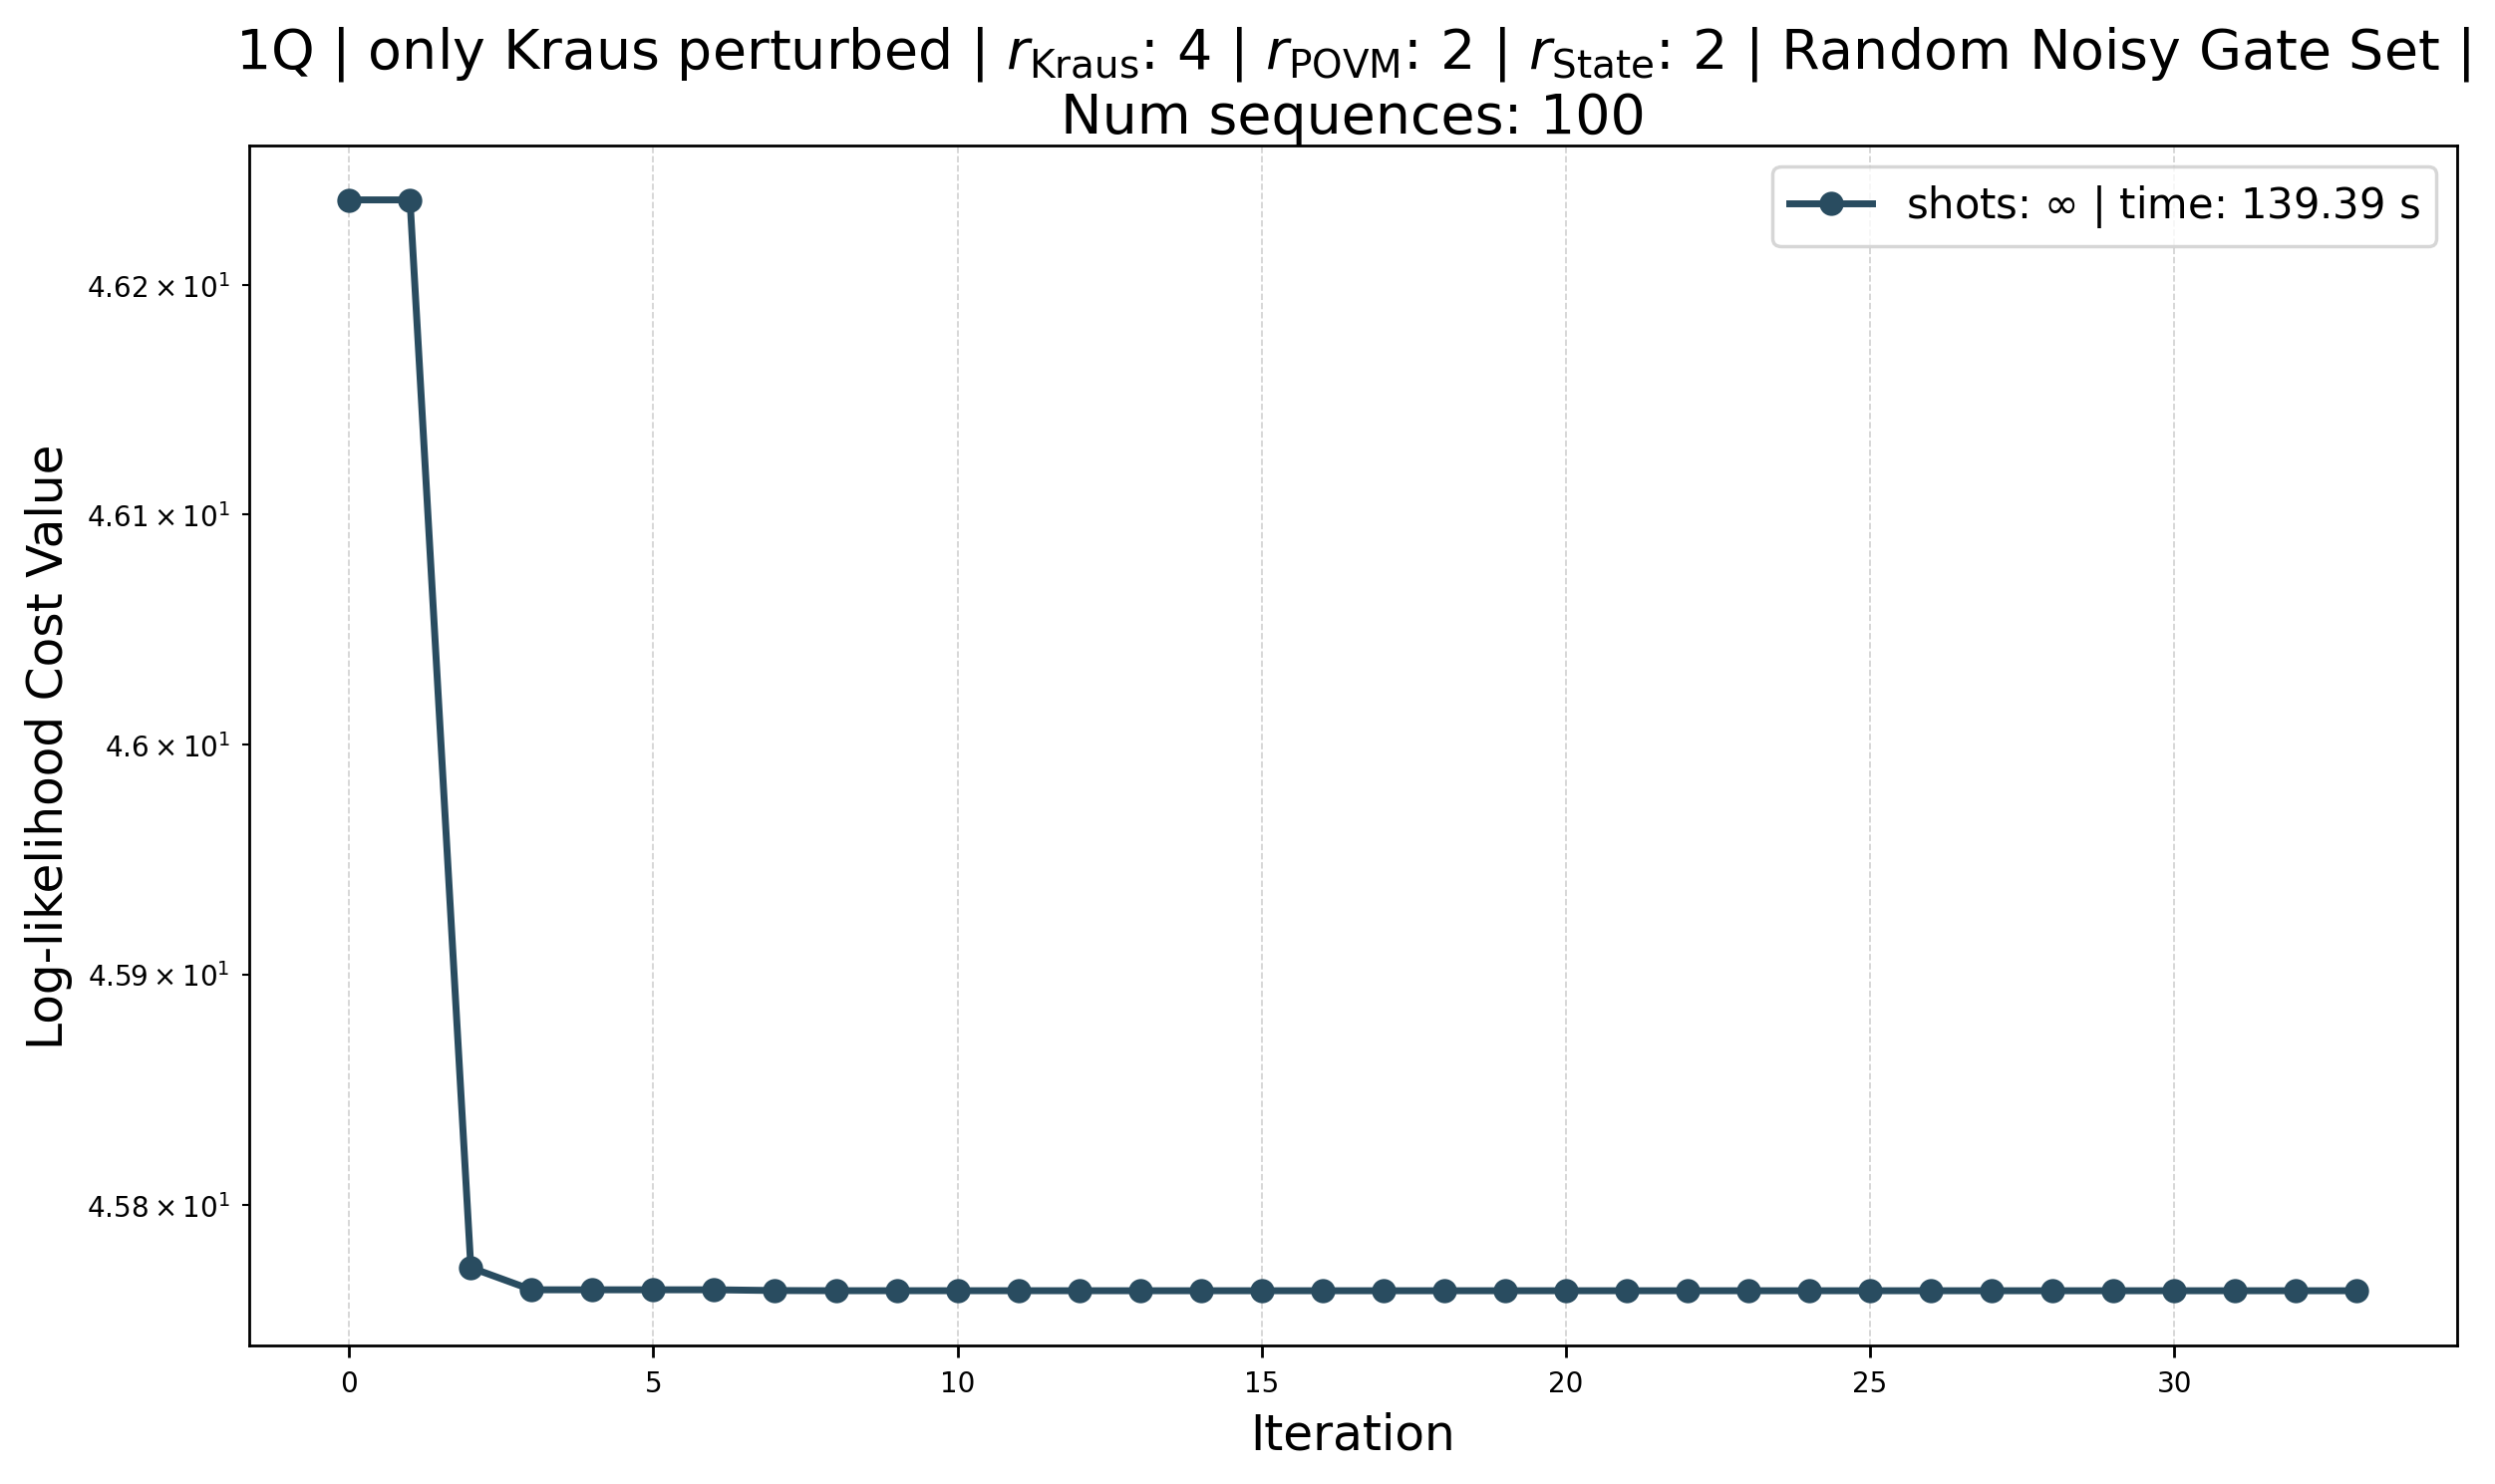

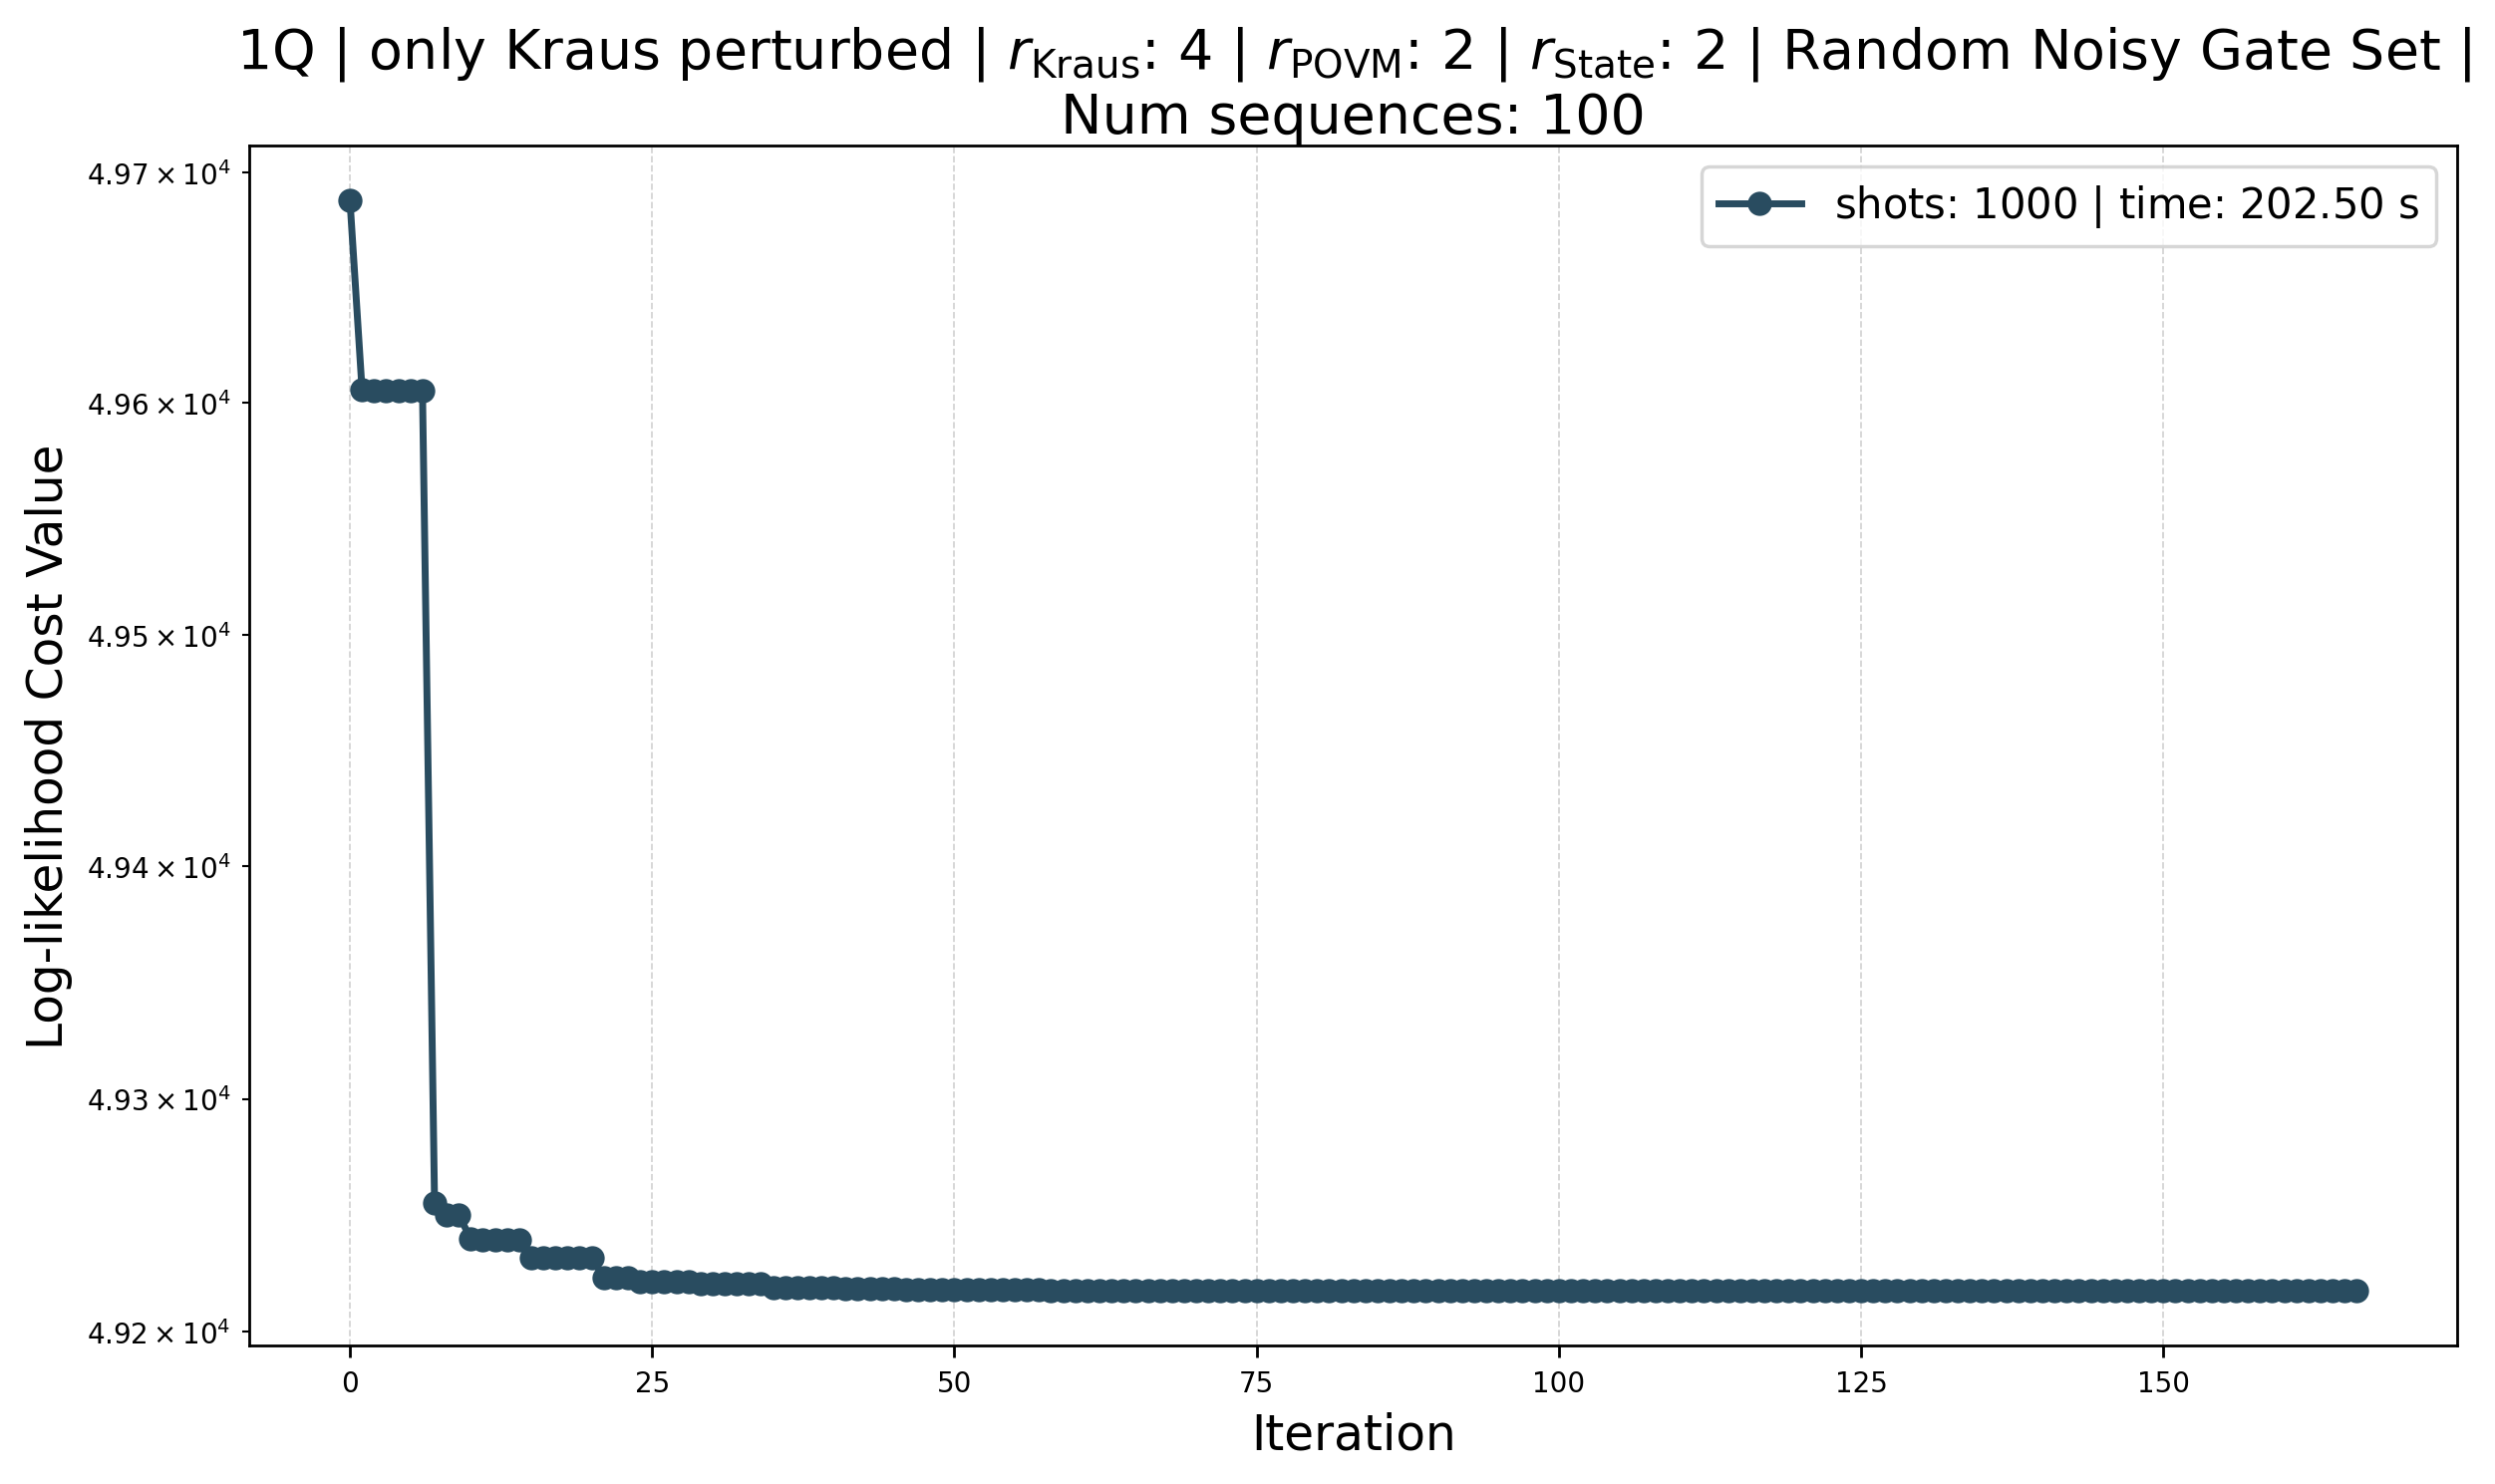

In [97]:
cost_fns_log_likelihood = [result["cost_fn_history"]["main"] for result in optimization_results_list]

plot_cost_function(cost_fns_log_likelihood[:1], title=title_100_seq, labels=labels[:1], comparison_yline=None, ylabel="Log-likelihood Cost Value")

plot_cost_function(cost_fns_log_likelihood[1:], title=title_100_seq, labels=labels[1:], comparison_yline=None, ylabel="Log-likelihood Cost Value")

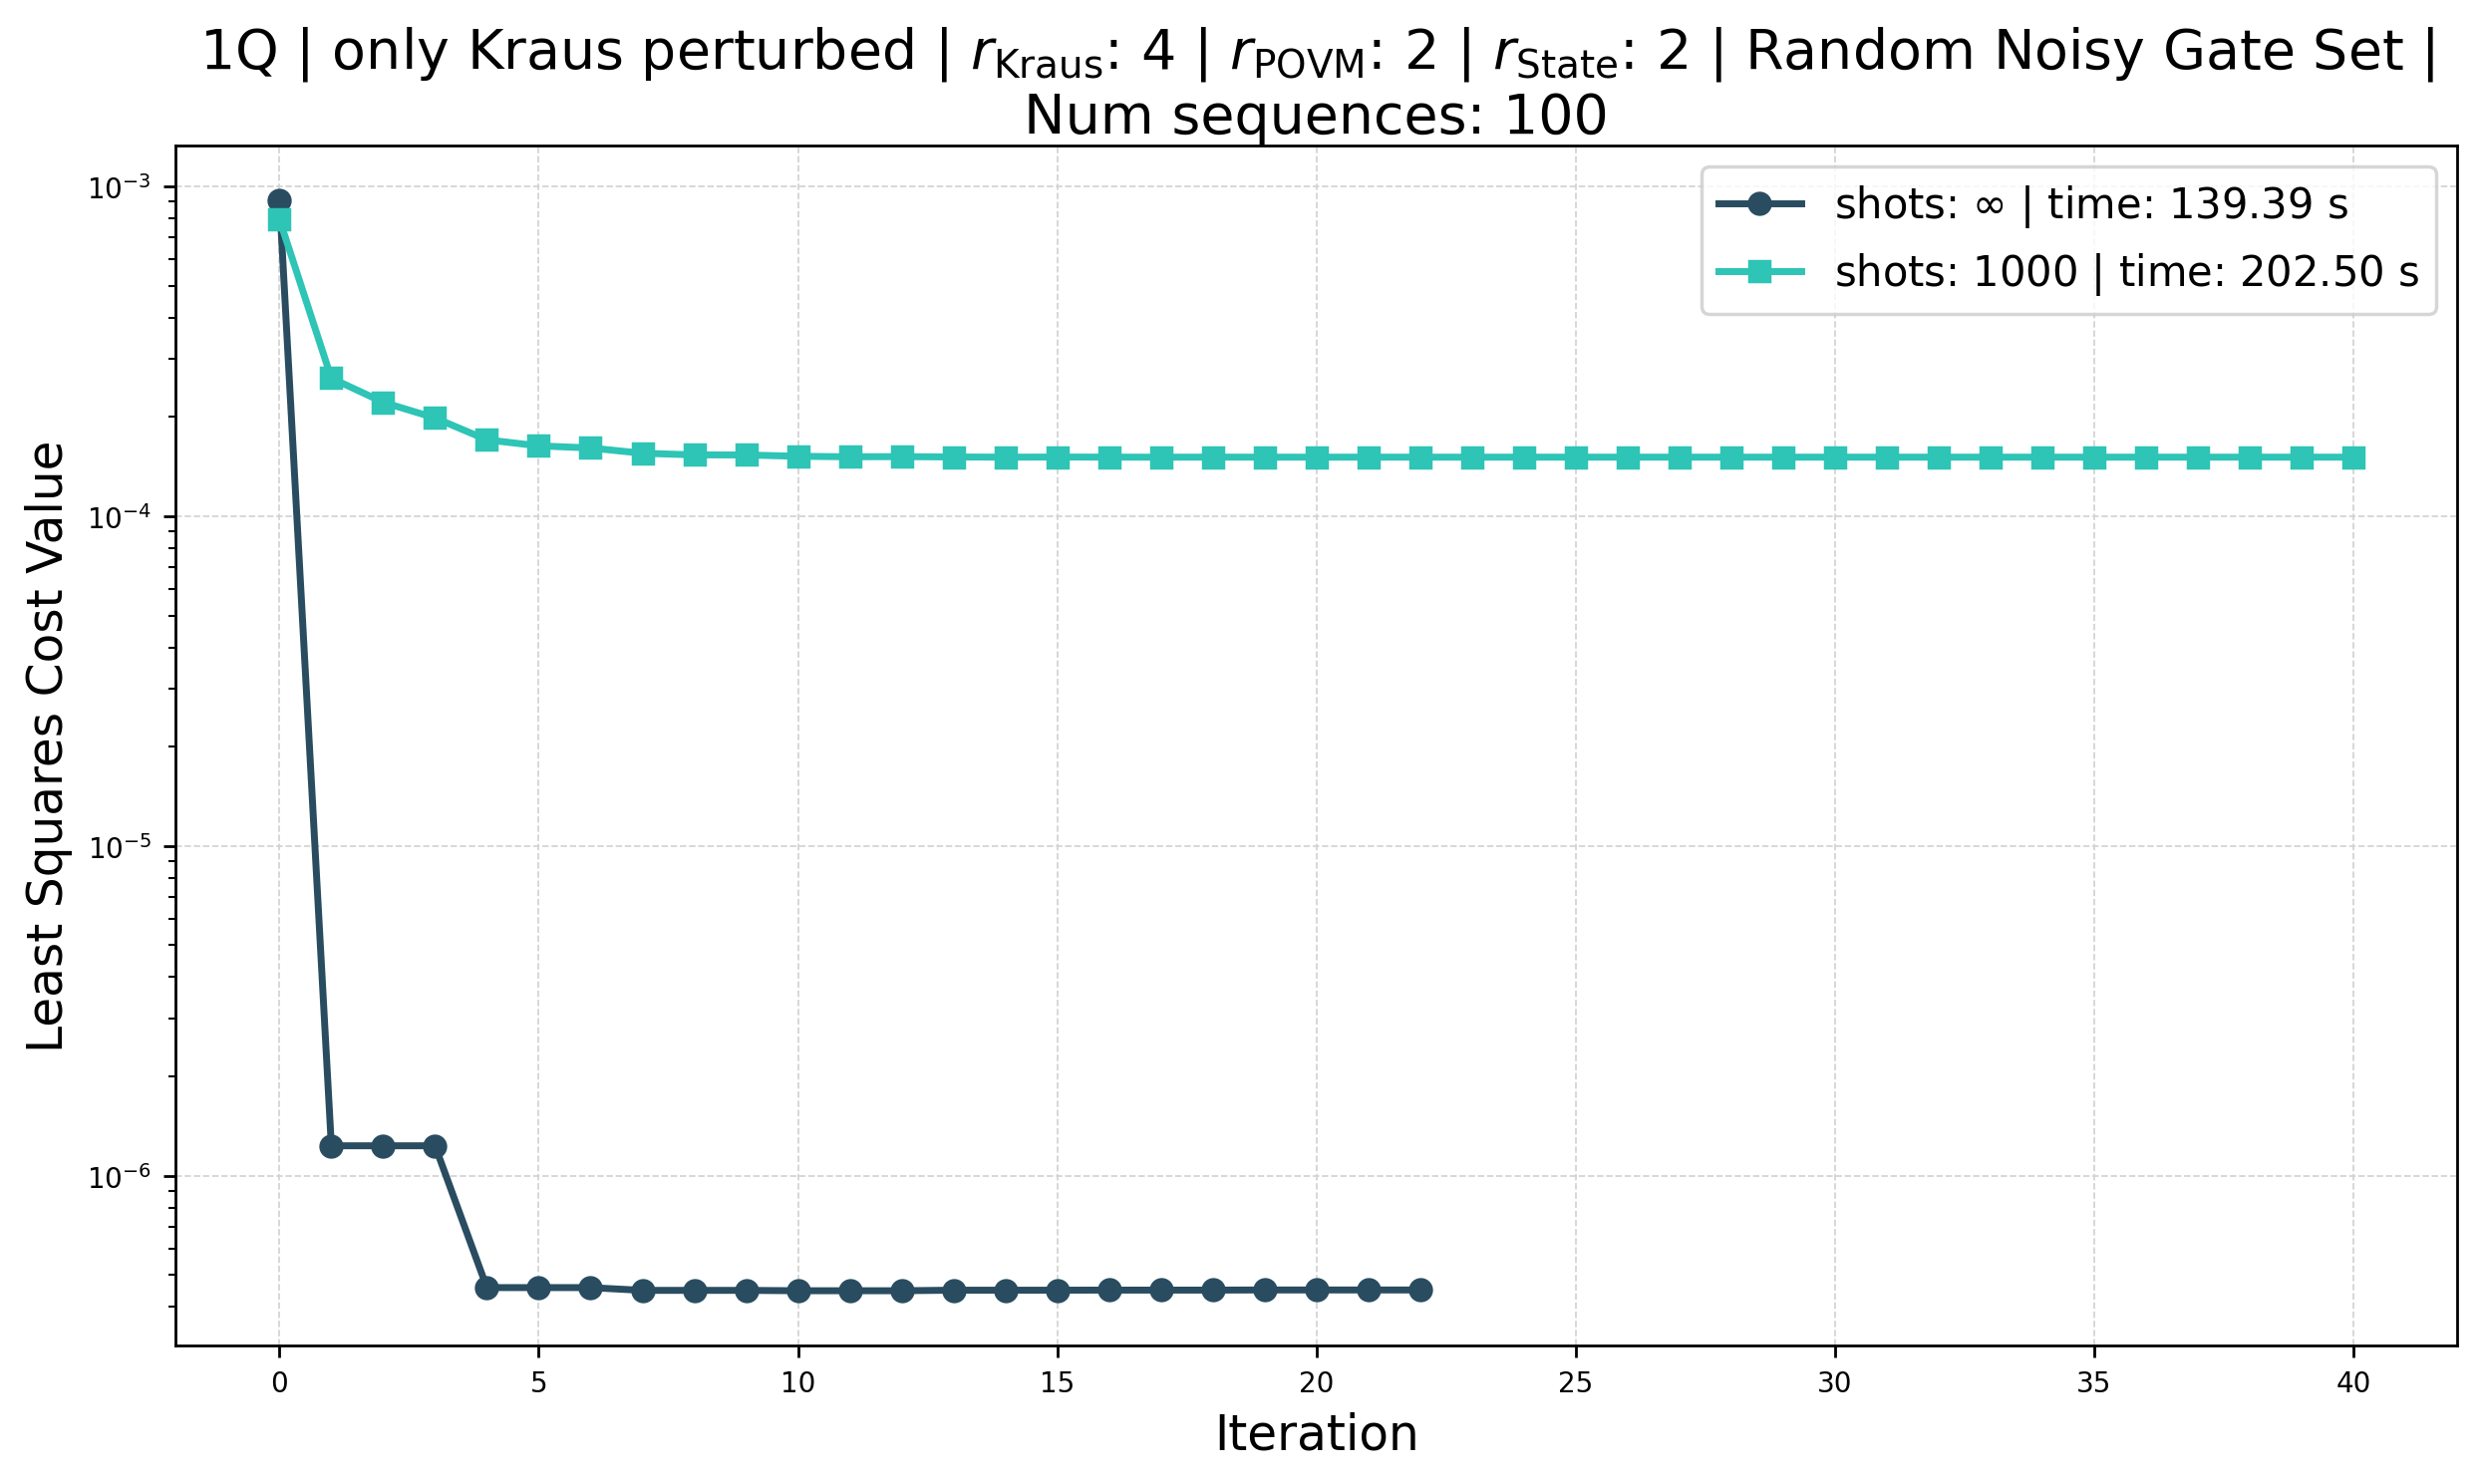

In [98]:
cost_fns_least_squares = [results["cost_fn_history"]["least_squares"] for results in optimization_results_list]

plot_cost_function(cost_fns_least_squares, title=title_100_seq, labels=labels, comparison_yline=None, ylabel="Least Squares Cost Value")

In [89]:
kraus_tensor_optimized_exact = optimization_results_100_seq_exact["optimized_operators"]["kraus"]

fidelity_kraus_init_vs_noisy_optimized_exact = process_fidelity(kraus_tensor_est=kraus_tensor_optimized_exact, kraus_tensor_target=kraus_tensor_noisy, unitary=True)

kraus_tensor_optimized_1000_shots = optimization_results_100_seq_1000_shots["optimized_operators"]["kraus"]

fidelity_kraus_init_vs_noisy_optimized_1000_shots = process_fidelity(kraus_tensor_est=kraus_tensor_optimized_1000_shots, kraus_tensor_target=kraus_tensor_noisy, unitary=True)

print(f"Fidelity between noisy and initial Kraus tensors: {fidelity_kraus_init_vs_noisy}")
print(f"Fidelity between noisy and optimized Kraus tensors (exact): {fidelity_kraus_init_vs_noisy_optimized_exact}")
print(f"Fidelity between noisy and optimized Kraus tensors (1000 shots): {fidelity_kraus_init_vs_noisy_optimized_1000_shots}")

Fidelity between noisy and initial Kraus tensors: 2.9951561294286773
Fidelity between noisy and optimized Kraus tensors (exact): 2.9998500577757032
Fidelity between noisy and optimized Kraus tensors (1000 shots): 2.99918095177901


# MVE vs number of sequences

In [102]:
import numpy as np
num_sequences_list = np.logspace(1,7,7, base=2)
num_sequences_list

array([  2.,   4.,   8.,  16.,  32.,  64., 128.])

In [ ]:
optimization_results_vs_sequences_exact = []
for num_seq in num_sequences_list:
    print(f"Running optimization for num_seq={num_seq}")
    print("--------------------------------")
    optimization_result = run_optimization_workflow(
        num_sequences=num_seq,
        num_shots=1,#inifinite shots for exact probabilities
        init_operators=init_gate_set_psd,
        operators_psd_true=noisy_gate_set_psd,
        target_superops=target_gate_set_superops,
        use_exact_probabilities=True,
        optimization_options=optimization_options,
        warmup_run=False,
        use_log_likelihood=True,
        compute_least_squares=1, # to compute after every operator
        optimization_verbose=True, # for debugging
        )
    print(f"Finished optimization for num_seq={num_seq}")
    print("--------------------------------")
    optimization_results_vs_sequences_exact.append(optimization_result)

Running optimization for num_seq=2.0
--------------------------------
Using exact probabilities 🔪
Using log-likelihood for the cost function optimization 🧮
⚠️ Computing least squares values during optimization. This may add additional computational overhead. ⚠️
🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-19]: TrustRegionOptions
povm: Schedule:
  [0-19]: TrustRegionOptions
state: Schedule:
  [0-19]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-11 
+ Gradient(s) Norm(s) 📐
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 1.391230e+00. |r∇f(x)|: 1.252028e+02. Radius: 1.00e-01
Update rejected ❌.
TR Iteration: 1. f(x): 1.391230e+00. |r∇f(x)|: 1.252028e+02. Radius: 2.50e-02
Update rejected ❌.
TR Iteration: 2. f(x): 1.391230e+00. |r∇f(x)|: 1.252028e+02. Radius: 6.25e-03
Update rejected ❌.
TR Iteration: 3. f(x): 1.391230e+00. |r∇f(x)|: 1.252028e+02. Radius: 1.56e-03
Update rejected ❌.
TR Iteration: 4. f(x): 1.39123

/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/simulate.py:460: UserWarning: Setting num_shots=1 when using exact probs.
  "indices_list": indices_list,


TR Iteration: 1. f(x): 1.386641e+00. |r∇f(x)|: 5.279987e-03. Radius: 1.00e-01
TR Iteration: 2. f(x): 1.386640e+00. |r∇f(x)|: 3.362144e-06. Radius: 1.00e-01
(RTR) Stopping criteria met. 🚨 |r∇f(x)|/|r∇f(x_0)| = 2.526146e-12
Optimization finished ✅. 
 Iters: 3. f(x): 1.386640e+00. |r∇f(x)|: 1.183338e-12. Radius: 1.00e-01. Rejections: 0
👾 Least squares value after Kraus: 5.225245e-11 👾

 🎯 [Kraus] Relative change in cost function value: 1.92e-03. Target: 1.00e-11.
🚀 TR started for operator: state 🚀.
TR Iteration: 0. f(x): 1.386640e+00. |r∇f(x)|: 1.252028e+02. Radius: 1.00e-01
Update rejected ❌.
TR Iteration: 1. f(x): 1.386640e+00. |r∇f(x)|: 1.252028e+02. Radius: 2.50e-02
Update rejected ❌.
TR Iteration: 2. f(x): 1.386640e+00. |r∇f(x)|: 1.252028e+02. Radius: 6.25e-03
Update rejected ❌.
TR Iteration: 3. f(x): 1.386640e+00. |r∇f(x)|: 1.252028e+02. Radius: 1.56e-03
Update rejected ❌.
TR Iteration: 4. f(x): 1.386640e+00. |r∇f(x)|: 1.252028e+02. Radius: 3.91e-04
Update rejected ❌.
Optimization f

/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/simulate.py:460: UserWarning: Setting num_shots=1 when using exact probs.
  "indices_list": indices_list,


TR Iteration: 2. f(x): 2.079680e+00. |r∇f(x)|: 4.108765e-03. Radius: 1.00e-01
TR Iteration: 3. f(x): 2.079678e+00. |r∇f(x)|: 3.953534e-06. Radius: 1.00e-01
(RTR) Stopping criteria met. 🚨 |r∇f(x)|/|r∇f(x_0)| = 1.791734e-12
Optimization finished ✅. 
 Iters: 4. f(x): 2.079678e+00. |r∇f(x)|: 3.594539e-12. Radius: 1.00e-01. Rejections: 0
👾 Least squares value after Kraus: 3.918933e-11 👾

 🎯 [Kraus] Relative change in cost function value: 8.01e-03. Target: 1.00e-11.
🚀 TR started for operator: state 🚀.
TR Iteration: 0. f(x): 2.079678e+00. |r∇f(x)|: 1.252028e+02. Radius: 1.00e-01
Update rejected ❌.
TR Iteration: 1. f(x): 2.079678e+00. |r∇f(x)|: 1.252028e+02. Radius: 2.50e-02
Update rejected ❌.
TR Iteration: 2. f(x): 2.079678e+00. |r∇f(x)|: 1.252028e+02. Radius: 6.25e-03
Update rejected ❌.
TR Iteration: 3. f(x): 2.079678e+00. |r∇f(x)|: 1.252028e+02. Radius: 1.56e-03
Update rejected ❌.
TR Iteration: 4. f(x): 2.079678e+00. |r∇f(x)|: 1.252028e+02. Radius: 3.91e-04
Update rejected ❌.
Optimization f

...

Update rejected ❌.
TR Iteration: 2. f(x): 1.402087e+01. |r∇f(x)|: 1.252097e+02. Radius: 6.25e-03
Update rejected ❌.
TR Iteration: 3. f(x): 1.402087e+01. |r∇f(x)|: 1.252097e+02. Radius: 1.56e-03
Update rejected ❌.
TR Iteration: 4. f(x): 1.402087e+01. |r∇f(x)|: 1.252097e+02. Radius: 3.91e-04
Update rejected ❌.
Optimization finished ✅. 
 Iters: 5. f(x): 1.402087e+01. |r∇f(x)|: 1.252097e+02. Radius: 9.77e-05. Rejections: 5
👾 Least squares value after POVM: 7.099422e-04 👾

 🎯 [Povm] Relative change in cost function value: 0.00e+00. Target: 1.00e-11.
🚀 TR started for operator: kraus 🚀.
TR Iteration: 0. f(x): 1.402087e+01. |r∇f(x)|: 5.760636e+00. Radius: 1.00e-01
TR Iteration: 1. f(x): 1.387198e+01. |r∇f(x)|: 7.129955e-01. Radius: 1.00e-01
TR Iteration: 2. f(x): 1.386878e+01. |r∇f(x)|: 1.920154e-01. Radius: 1.00e-01
Update rejected ❌.
TR Iteration: 3. f(x): 1.386878e+01. |r∇f(x)|: 1.920154e-01. Radius: 2.50e-02
Update rejected ❌.
TR Iteration: 4. f(x): 1.386878e+01. |r∇f(x)|: 1.920154e-01. Ra

/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/simulate.py:460: UserWarning: Setting num_shots=1 when using exact probs.
  "indices_list": indices_list,


Update rejected ❌.
TR Iteration: 1. f(x): 2.950878e+01. |r∇f(x)|: 1.252301e+02. Radius: 2.50e-02
Update rejected ❌.
TR Iteration: 2. f(x): 2.950878e+01. |r∇f(x)|: 1.252301e+02. Radius: 6.25e-03
Update rejected ❌.
TR Iteration: 3. f(x): 2.950878e+01. |r∇f(x)|: 1.252301e+02. Radius: 1.56e-03
Update rejected ❌.
TR Iteration: 4. f(x): 2.950878e+01. |r∇f(x)|: 1.252301e+02. Radius: 3.91e-04
Update rejected ❌.
Optimization finished ✅. 
 Iters: 5. f(x): 2.950878e+01. |r∇f(x)|: 1.252301e+02. Radius: 9.77e-05. Rejections: 5
👾 Least squares value after POVM: 1.151103e-03 👾

 🎯 [Povm] Relative change in cost function value: 0.00e+00. Target: 1.00e-11.
🚀 TR started for operator: kraus 🚀.
TR Iteration: 0. f(x): 2.950878e+01. |r∇f(x)|: 1.899900e+01. Radius: 1.00e-01
TR Iteration: 1. f(x): 2.914949e+01. |r∇f(x)|: 3.067332e+00. Radius: 1.00e-01
TR Iteration: 2. f(x): 2.912472e+01. |r∇f(x)|: 6.614650e-01. Radius: 1.00e-01
Update rejected ❌.
TR Iteration: 3. f(x): 2.912472e+01. |r∇f(x)|: 6.614650e-01. Ra

/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/simulate.py:460: UserWarning: Setting num_shots=1 when using exact probs.
  "indices_list": indices_list,


Update rejected ❌.
TR Iteration: 1. f(x): 5.957089e+01. |r∇f(x)|: 1.253051e+02. Radius: 2.50e-02
Update rejected ❌.
TR Iteration: 2. f(x): 5.957089e+01. |r∇f(x)|: 1.253051e+02. Radius: 6.25e-03
Update rejected ❌.
TR Iteration: 3. f(x): 5.957089e+01. |r∇f(x)|: 1.253051e+02. Radius: 1.56e-03
Update rejected ❌.
TR Iteration: 4. f(x): 5.957089e+01. |r∇f(x)|: 1.253051e+02. Radius: 3.91e-04
Update rejected ❌.
Optimization finished ✅. 
 Iters: 5. f(x): 5.957089e+01. |r∇f(x)|: 1.253051e+02. Radius: 9.77e-05. Rejections: 5
👾 Least squares value after POVM: 8.884464e-04 👾

 🎯 [Povm] Relative change in cost function value: 0.00e+00. Target: 1.00e-11.
🚀 TR started for operator: kraus 🚀.
TR Iteration: 0. f(x): 5.957089e+01. |r∇f(x)|: 2.604538e+01. Radius: 1.00e-01
TR Iteration: 1. f(x): 5.895450e+01. |r∇f(x)|: 2.370162e+00. Radius: 1.00e-01
TR Iteration: 2. f(x): 5.893900e+01. |r∇f(x)|: 7.995771e-01. Radius: 1.00e-01
Update rejected ❌.
TR Iteration: 3. f(x): 5.893900e+01. |r∇f(x)|: 7.995771e-01. Ra

In [121]:
gst_superops_list = [res["superops_gauged"] for res in optimization_results_vs_sequences_exact]
num_shots_samples = 1000
num_random_runs = 10
length = 14

mve_results_over_sequences = variational_error_avg_and_std_from_list_of_superops(num_runs=num_random_runs, true_superops=noisy_gate_set_superop, gst_superops=gst_superops_list, length=length, samples=num_shots_samples, error_type="MVE")

mve_results_dict = {str(num_seq): {"mean": mean, "std": std} for num_seq, (mean, std) in zip(num_sequences_list, mve_results_over_sequences)}

Processing superop no.: 0
Processing superop no.: 1
Processing superop no.: 2
Processing superop no.: 3
Processing superop no.: 4
Processing superop no.: 5
Processing superop no.: 6


In [154]:
wve_results_over_sequences = variational_error_avg_and_std_from_list_of_superops(num_runs=num_random_runs, true_superops=noisy_gate_set_superop, gst_superops=gst_superops_list, length=length, samples=num_shots_samples, error_type="WVE")

wve_results_dict = {str(num_seq): {"mean": mean, "std": std} for num_seq, (mean, std) in zip(num_sequences_list, wve_results_over_sequences)}

Processing superop no.: 0
Processing superop no.: 1
Processing superop no.: 2
Processing superop no.: 3
Processing superop no.: 4
Processing superop no.: 5
Processing superop no.: 6


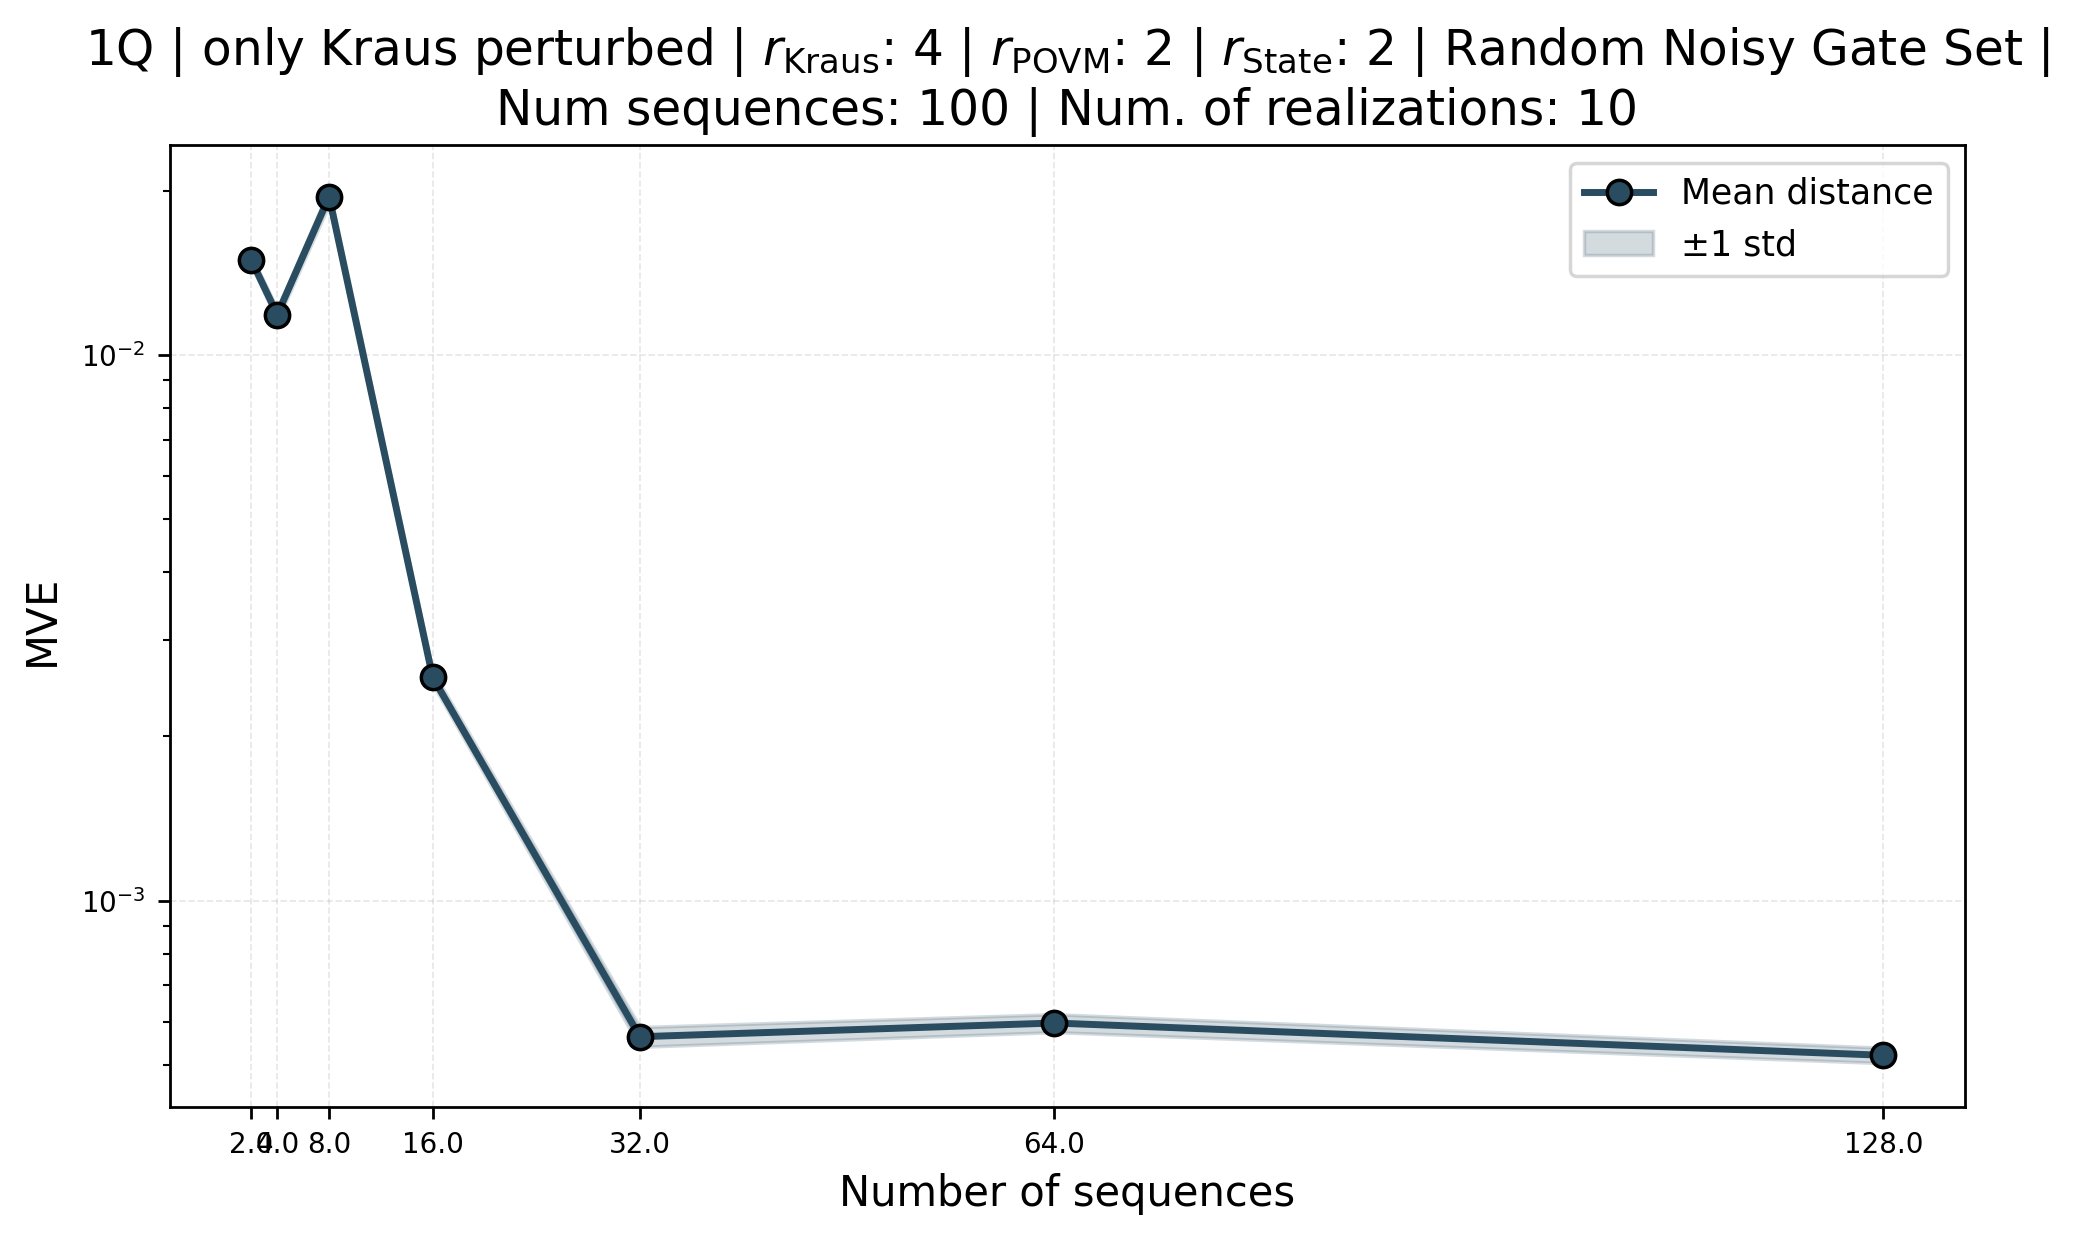

In [158]:
figure_mve = plot_mean_std_vs_x(
    mve_results_dict,
    title=title_100_seq + f" | Num. of realizations: {num_random_runs}",
    ylabel=r"$\text{MVE}$",
    use_log_scale="y",
)

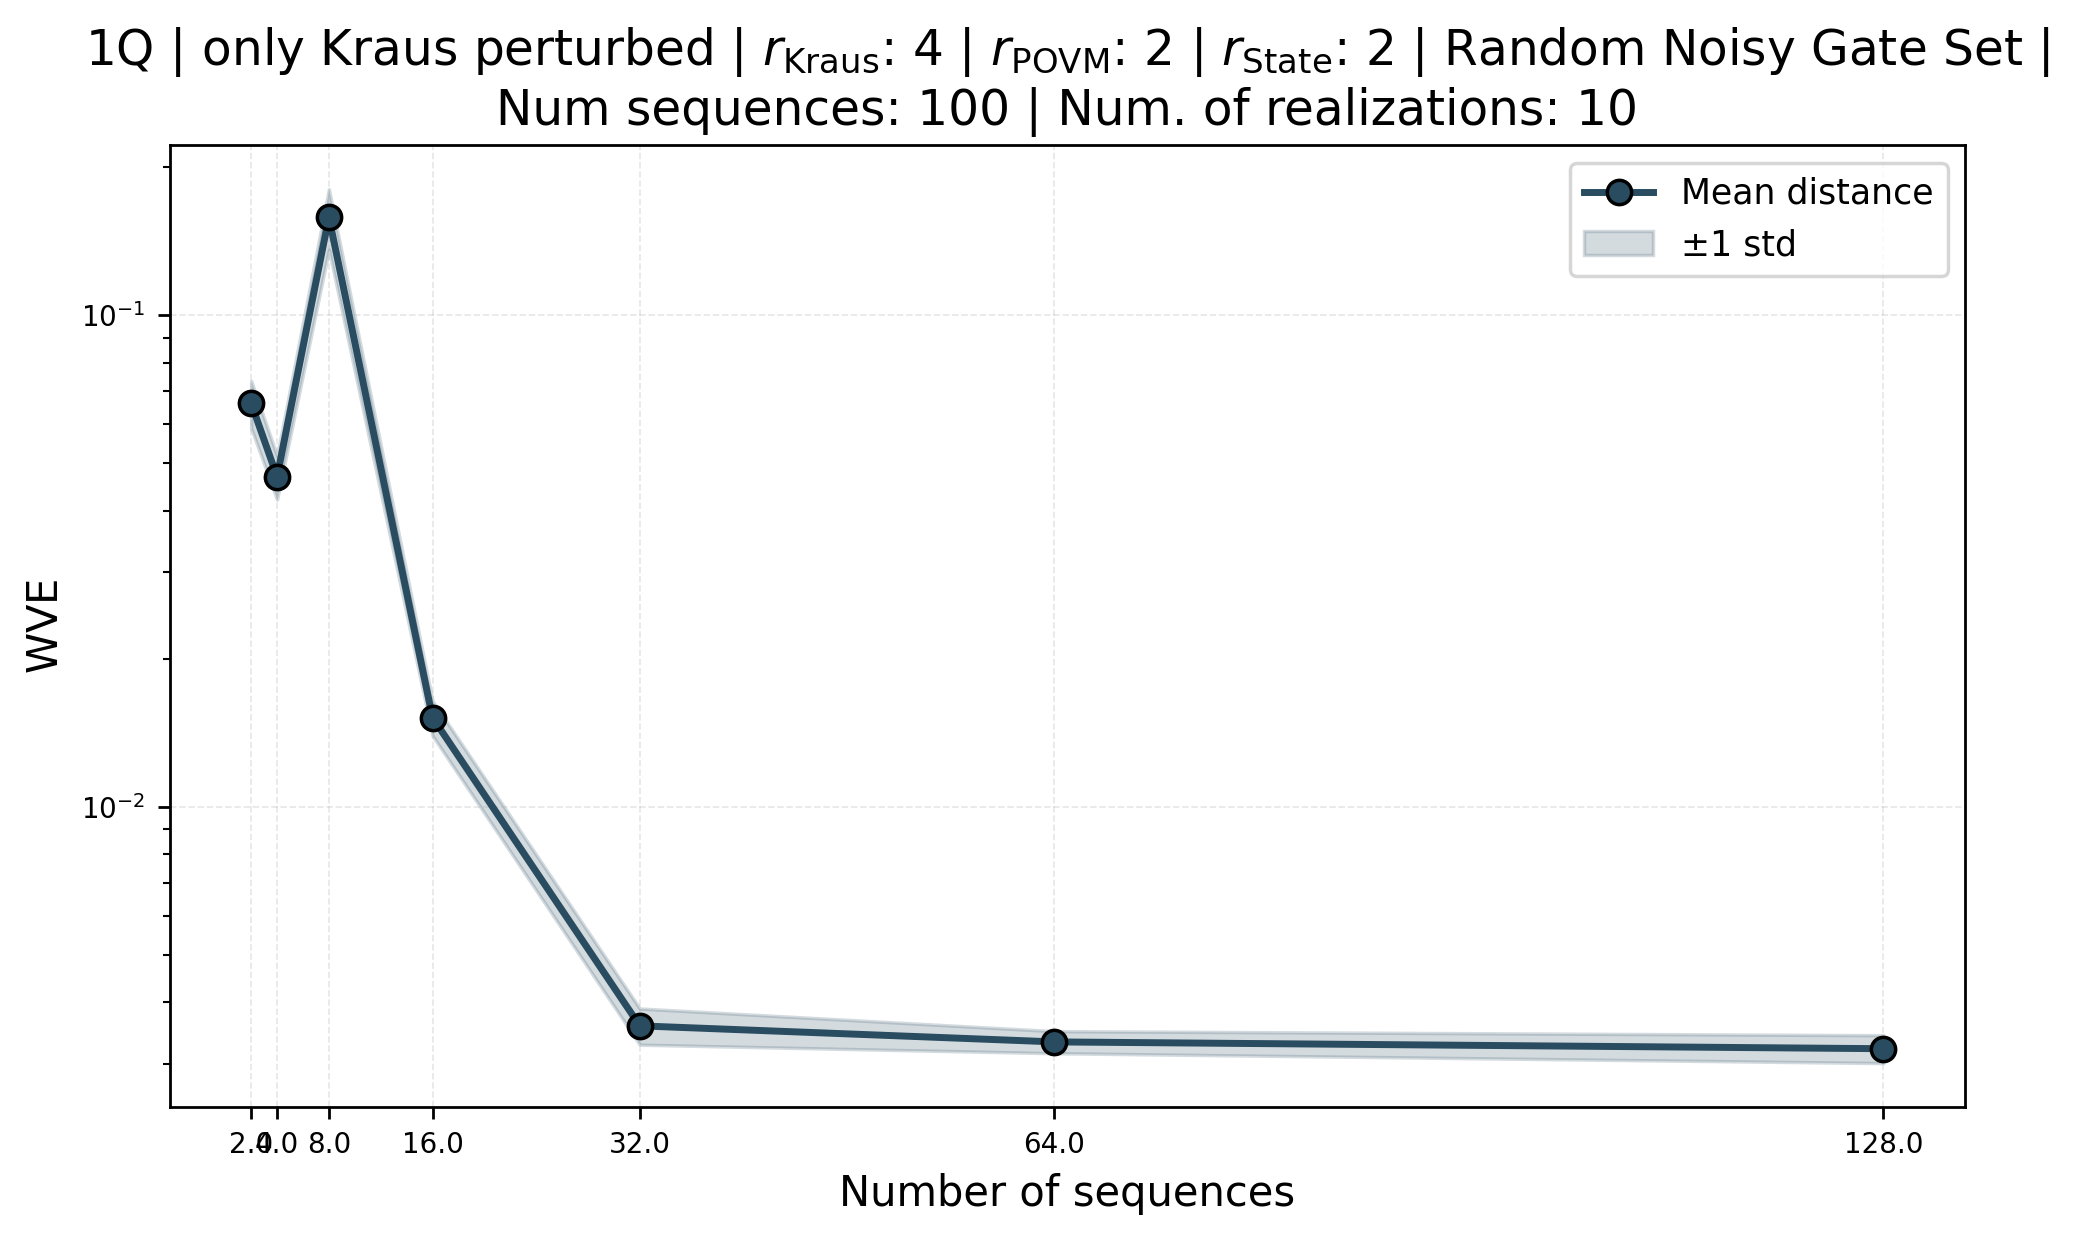

In [157]:
figure_wve = plot_mean_std_vs_x(
    wve_results_dict,
    title=title_100_seq + f" | Num. of realizations: {num_random_runs}",
    ylabel=r"$\text{WVE}$",
    use_log_scale="y",
    value_type="mean",
)

In [136]:
diamond_distances_mean_vs_sequences = compute_diamond_distances_from_list_of_superops(
    true_superops=noisy_gate_set_superop,
    gst_superops=gst_superops_list,
    operator_type="kraus",
    report="mean",
)

diamond_results_dict = {str(num_seq): {"mean": mean, "std": std} for num_seq, (mean, std) in zip(num_sequences_list, diamond_distances_mean_vs_sequences)}

💎 Computing diamond norm for superoperator 0 💎
💎 Computing diamond norm for superoperator 1 💎
💎 Computing diamond norm for superoperator 2 💎
💎 Computing diamond norm for superoperator 3 💎
💎 Computing diamond norm for superoperator 4 💎
💎 Computing diamond norm for superoperator 5 💎
💎 Computing diamond norm for superoperator 6 💎


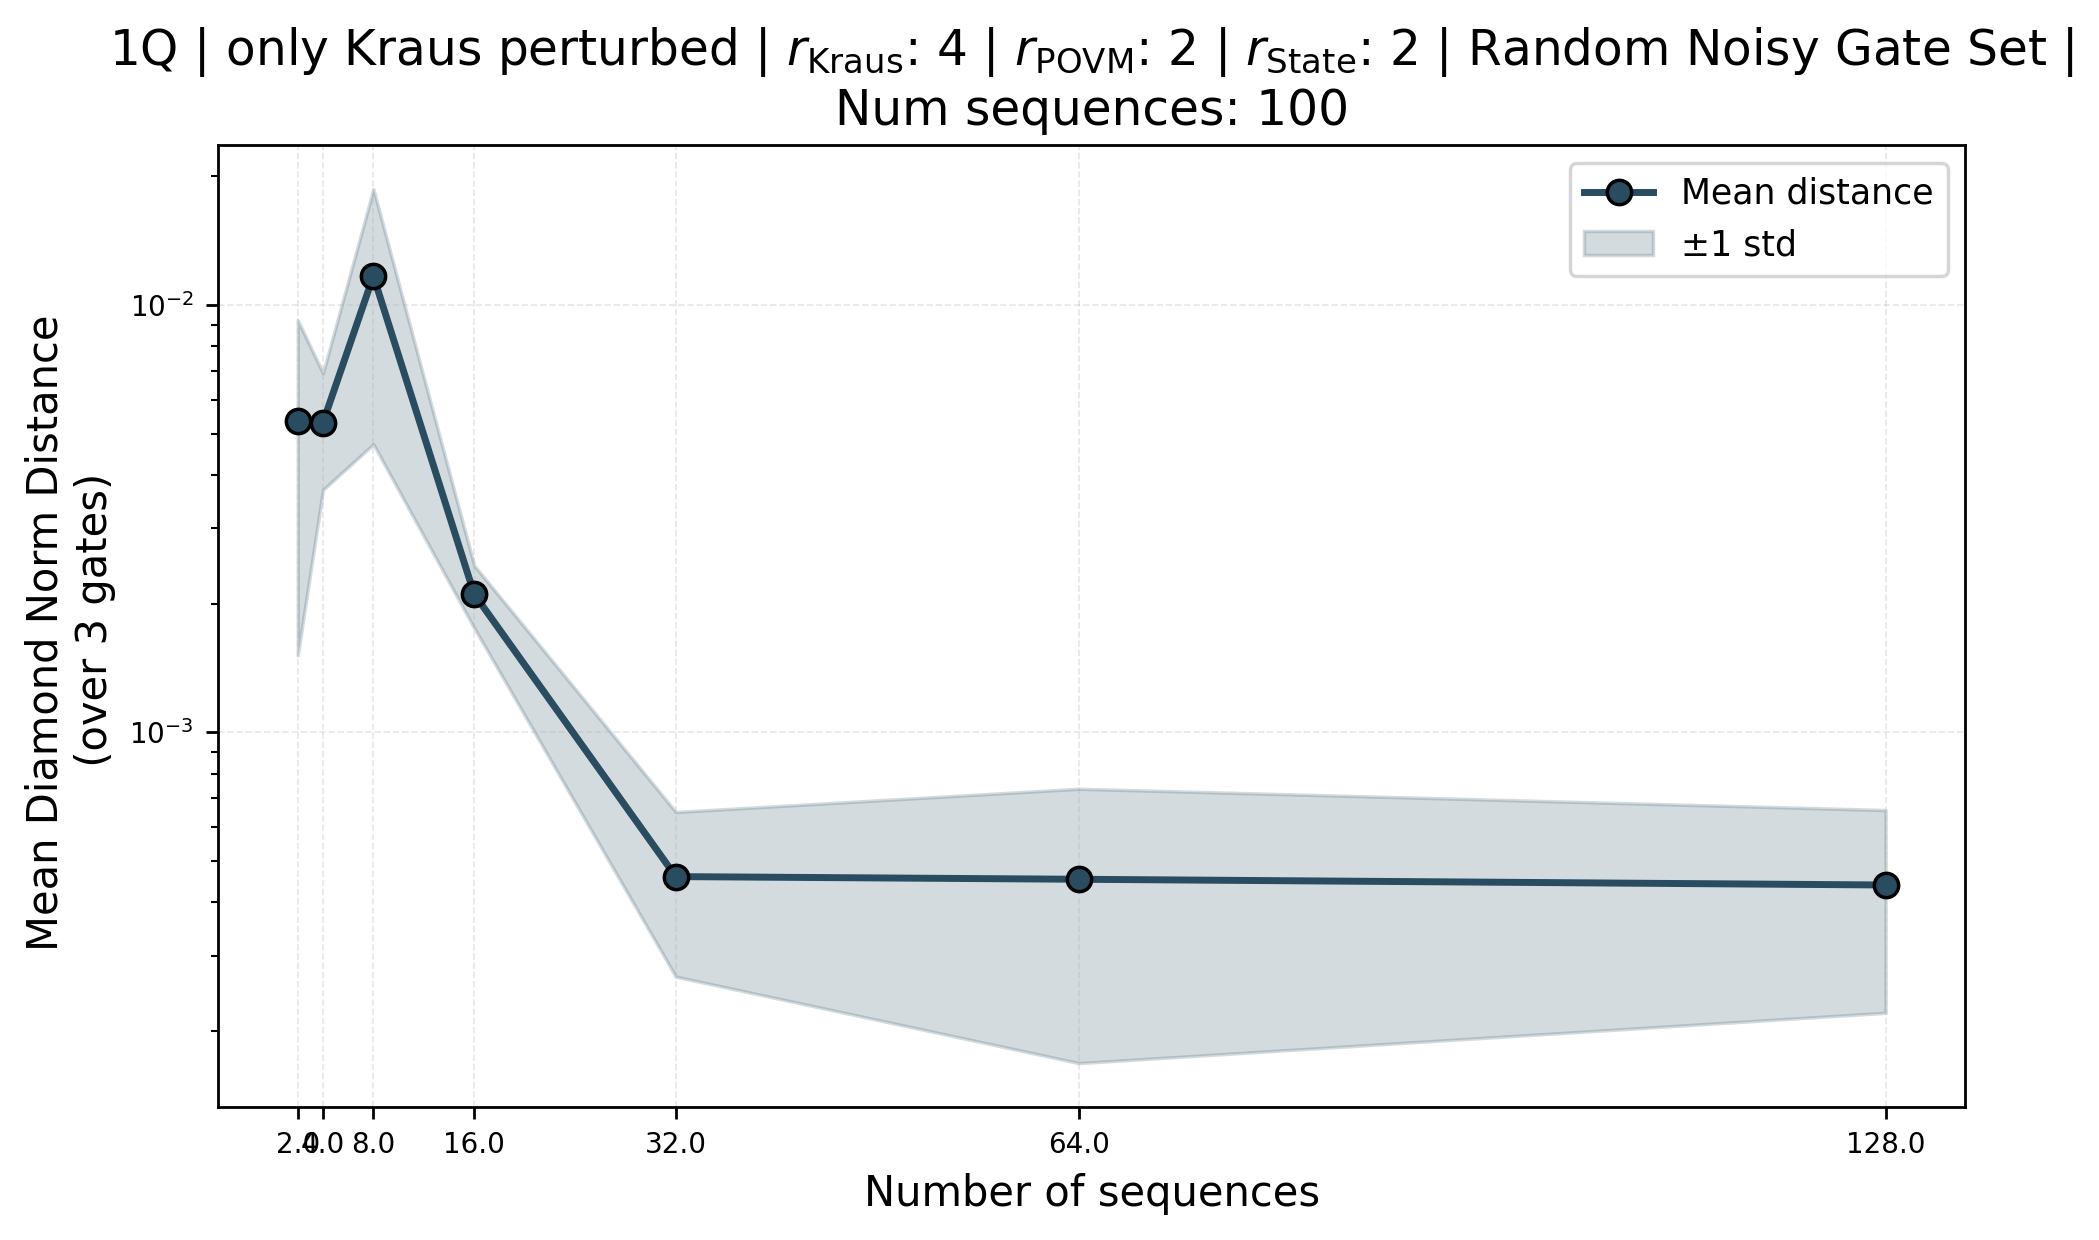

In [150]:
figure_diamond = plot_mean_std_vs_x(
    diamond_results_dict,
    title=title_100_seq,
    ylabel=f"Mean Diamond Norm Distance \n (over {num_gates} gates)",
    use_log_scale="y",
)

In [146]:
diamond_distances_max_vs_sequences = compute_diamond_distances_from_list_of_superops(
    true_superops=noisy_gate_set_superop,
    gst_superops=gst_superops_list,
    operator_type="kraus",
    report="max",
)

diamond_results_dict_max = {str(num_seq): {"max": max_val, "std": std} for num_seq, (max_val, std) in zip(num_sequences_list, diamond_distances_max_vs_sequences)}

💎 Computing diamond norm for superoperator 0 💎
💎 Computing diamond norm for superoperator 1 💎
💎 Computing diamond norm for superoperator 2 💎
💎 Computing diamond norm for superoperator 3 💎
💎 Computing diamond norm for superoperator 4 💎
💎 Computing diamond norm for superoperator 5 💎
💎 Computing diamond norm for superoperator 6 💎


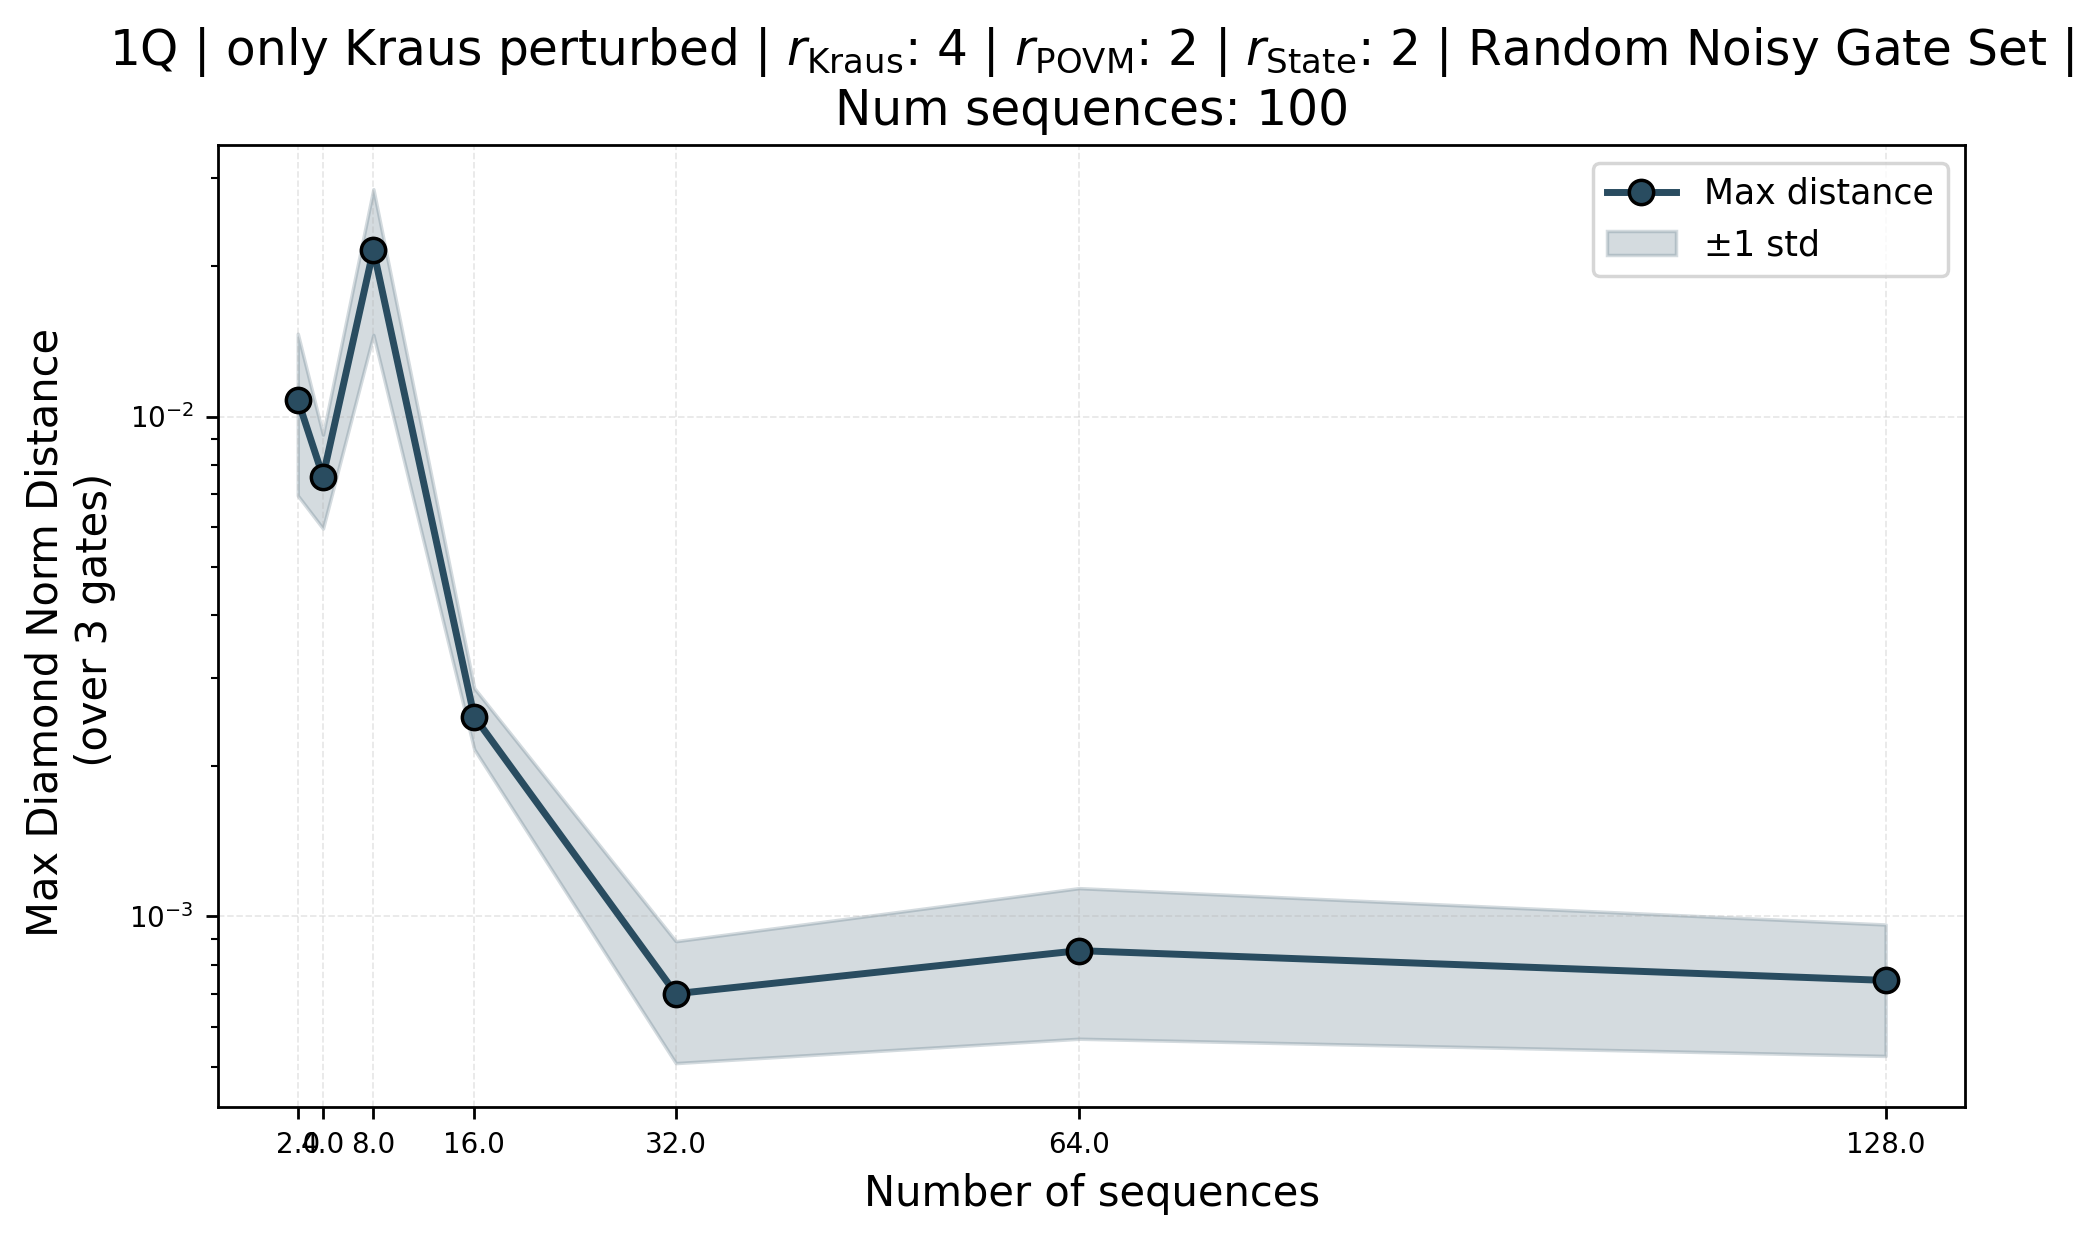

In [151]:
figure_diamond_max = plot_mean_std_vs_x(
    diamond_results_dict_max,
    title=title_100_seq,
    ylabel=f"Max Diamond Norm Distance \n (over {num_gates} gates)",
    use_log_scale="y",
    value_type="max",
)

## Least squares

In [129]:
cost_fn_ls_vs_sequences = [res["cost_fn_history"]["least_squares"] for res in optimization_results_vs_sequences_exact]

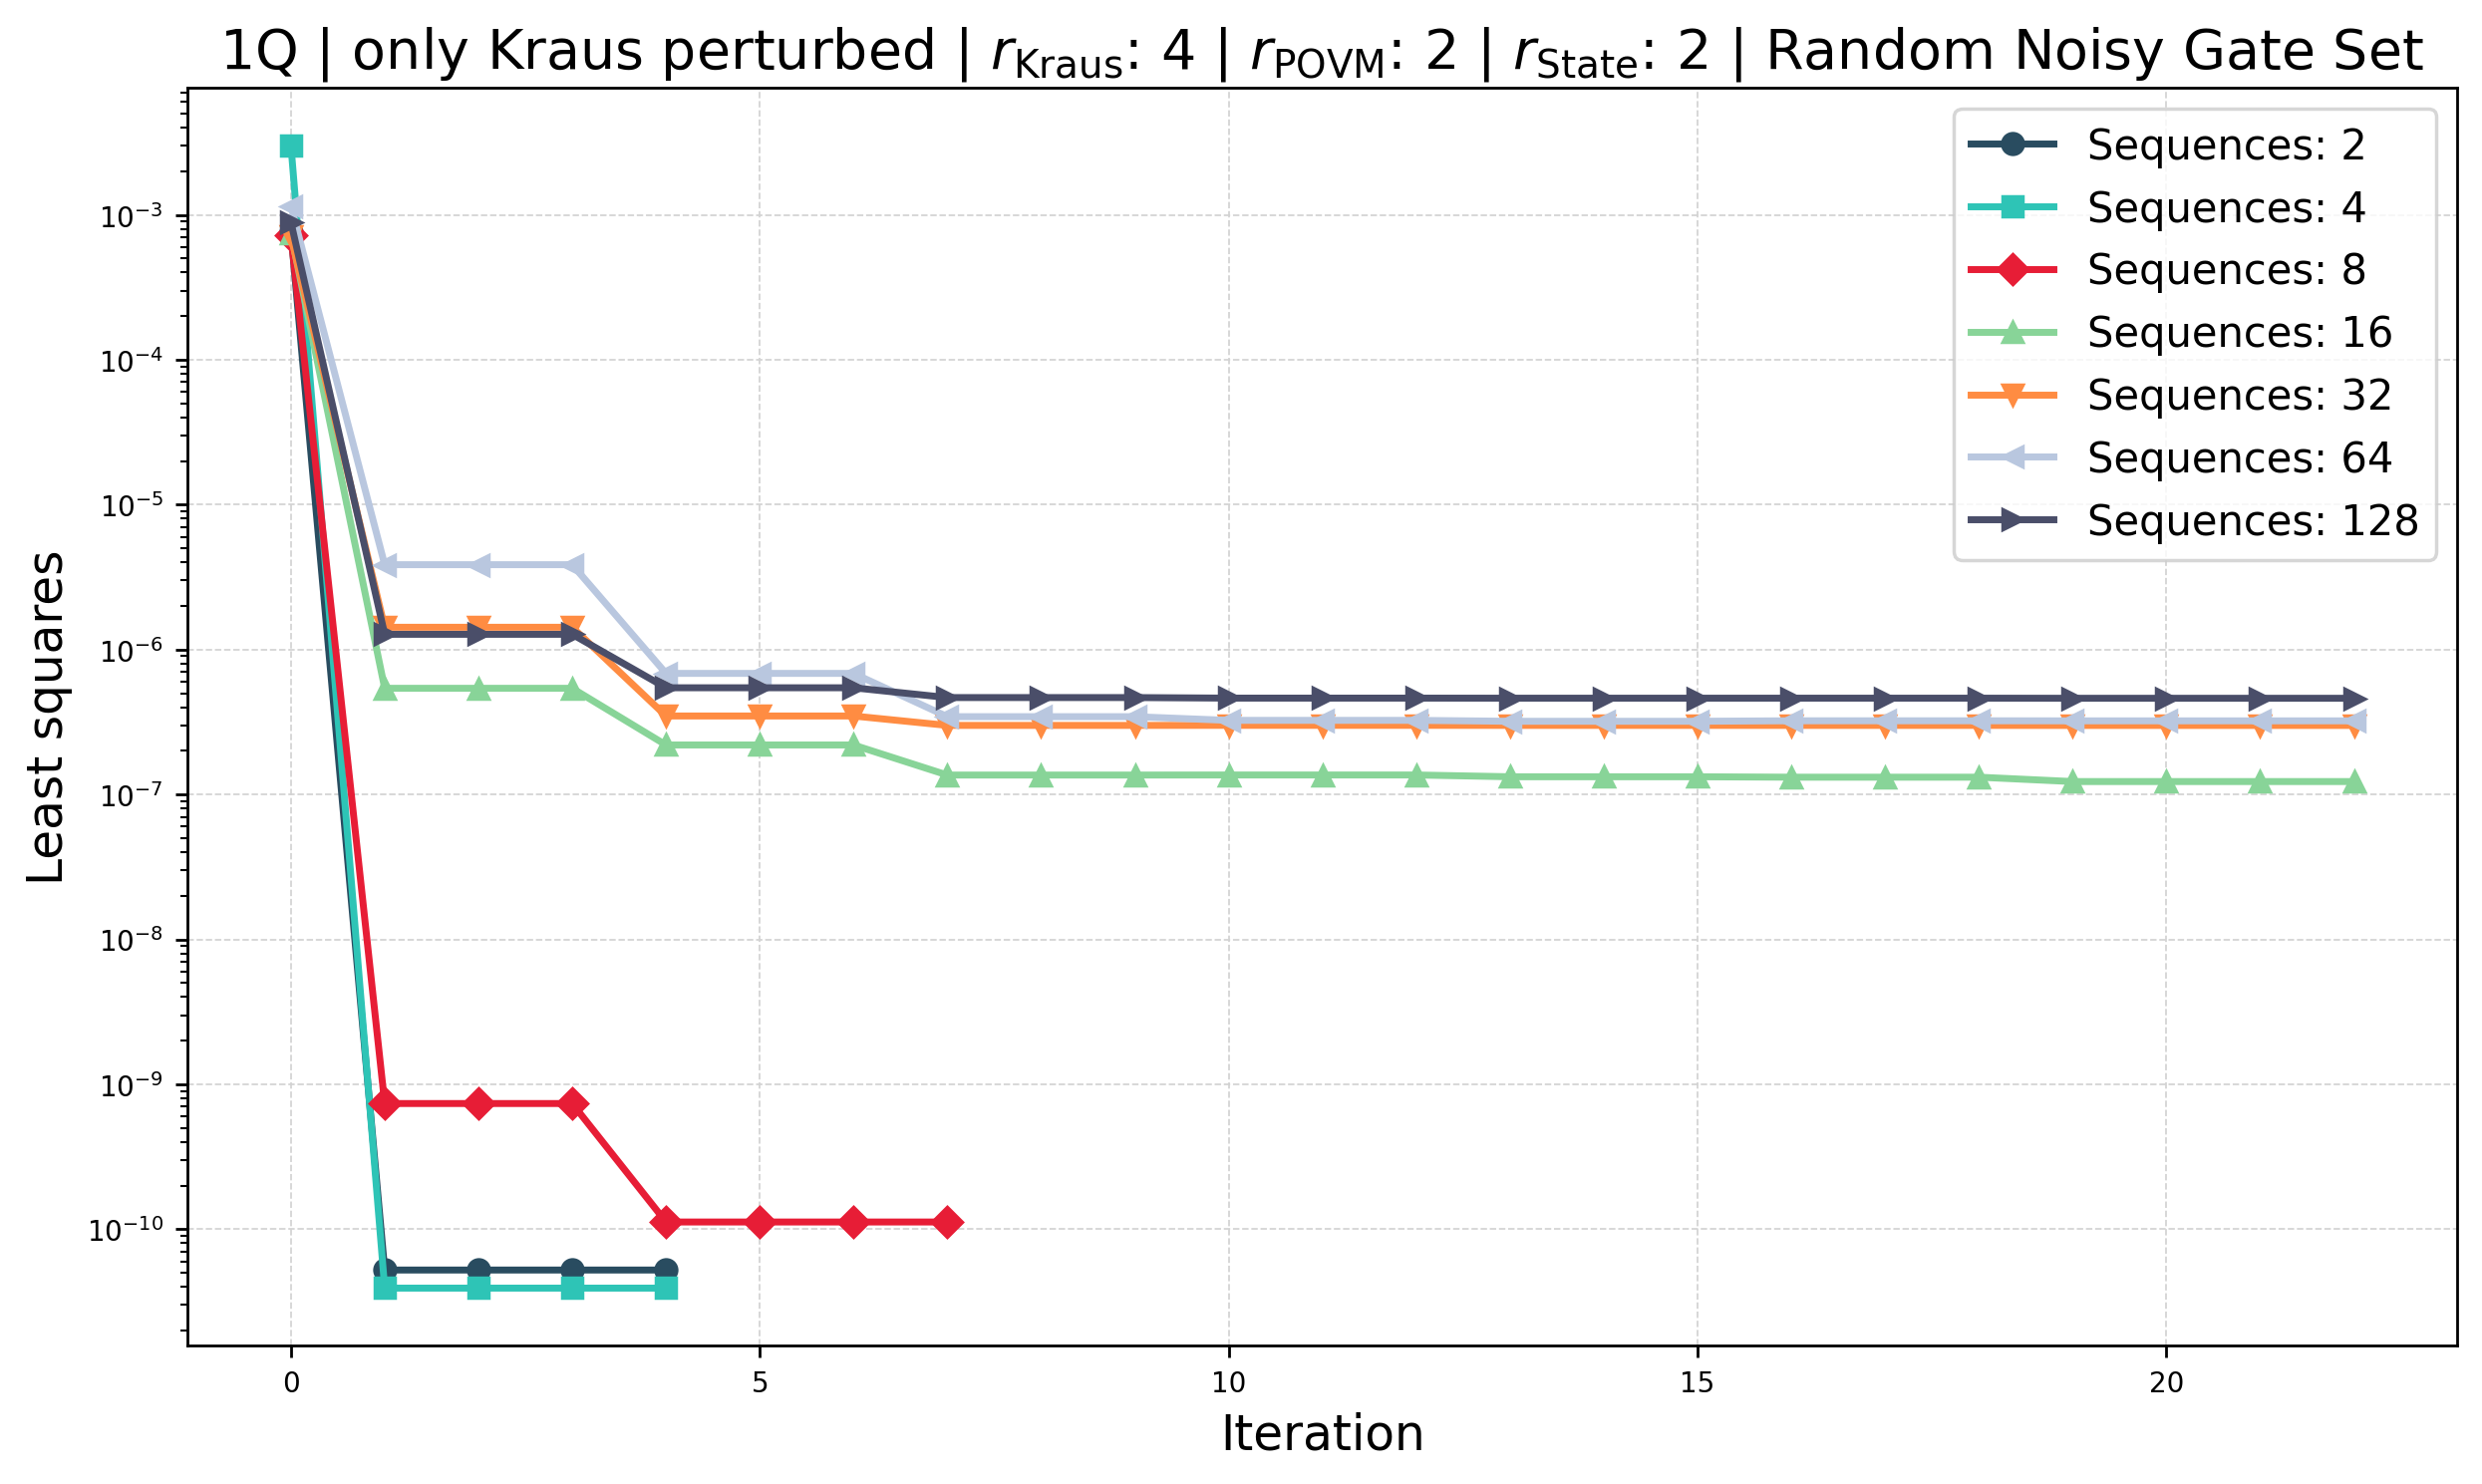

In [130]:
title_vs_sequences = rf"{num_qubits}Q | only Kraus perturbed | $r_\mathrm{{Kraus}}$: {kraus_rank} | $r_\mathrm{{POVM}}$: {povm_rank} | $r_\mathrm{{State}}$: {state_rank} | Random Noisy Gate Set "

labels_vs_sequences = [f"Sequences: {int(num_seq)}" for num_seq in num_sequences_list]

plot_cost_function(cost_fn_ls_vs_sequences, title=title_vs_sequences, labels=labels_vs_sequences, ylabel="Least squares")

# Closer look into smaller sequences transition

* Num. sequences: $n \leq 40$
* Change Kraus rank (1, 2, 3, 4)

In [161]:
from mGST.utility_functions_comparisons import get_initial_gate_set_for_optimization

In [160]:
num_sequences_list_small = np.arange(5, 45, 5)
num_sequences_list_small

array([ 5, 10, 15, 20, 25, 30, 35, 40])

In [196]:
tr_schedule_silence = OperatorSchedule.default(num_iterations_outer, TrustRegionOptions(num_iterations=num_iterations_tr, verbose=False, verbose_cg=False, num_iterations_cg=num_iterations_cg, tol_grad=tol_grad))


optimization_schedule_silence= {
    "kraus": tr_schedule_silence,
    "povm": tr_schedule_silence,
    "state": tr_schedule_silence
}

optimization_options_silence = {
    "schedule": optimization_schedule_silence,
    "num_iterations_outer": num_iterations_outer,
    "relative_precision": relative_precision,
    "global_gradient_norm_tol": global_grad_norm_tol
}
optimization_options_silence

{'schedule': {'kraus': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=False, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))]),
  'povm': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=False, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))]),
  'state': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=False, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))])},
 'num_iterations_outer': 20,
 'relative_precision': 1e-11,
 'global_gradient_norm_tol': 1e-10}

In [197]:
realizations = 10
optimization_results_all_realizations_exact_small = []
for idx in range(realizations):
    print(f"🧿 Realization {idx+1}/{realizations} 🧿")
    optimization_results_vs_sequences = []
    for num_seq in num_sequences_list_small:
        print(f"🏃 Running optimization for num_seq={num_seq} 🏃")
        print("--------------------------------")
        optimization_result_i = run_optimization_workflow(
            num_sequences=num_seq,
            num_shots=1,#inifinite shots for exact probabilities
            init_operators=init_gate_set_psd,
            operators_psd_true=noisy_gate_set_psd,
            target_superops=target_gate_set_superops,
            use_exact_probabilities=True,
            optimization_options=optimization_options_silence,
            warmup_run=False,
            use_log_likelihood=True,
            compute_least_squares=1, # to compute after every operator
            optimization_verbose=False, # we trust it (?)
            )
        print(f"🇫🇮 Finish(ed) optimization for num_seq={num_seq} 🇫🇮")
        print("--------------------------------")
        optimization_results_vs_sequences.append(optimization_result_i)
    optimization_results_all_realizations_exact_small.append(optimization_results_vs_sequences)

🧿 Realization 1/10 🧿
🏃 Running optimization for num_seq=5 🏃
--------------------------------
Using exact probabilities 🔪
Using log-likelihood for the cost function optimization 🧮
⚠️ Computing least squares values during optimization. This may add additional computational overhead. ⚠️
🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-19]: TrustRegionOptions
povm: Schedule:
  [0-19]: TrustRegionOptions
state: Schedule:
  [0-19]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-11 
+ Gradient(s) Norm(s) 📐
🚀 TR started for operator: povm 🚀.


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/simulate.py:460: UserWarning: Setting num_shots=1 when using exact probs.
  "indices_list": indices_list,


Optimization finished ✅. 
 Iters: 5. f(x): 1.421428e+00. |r∇f(x)|: 1.252028e+02. Radius: 9.77e-05. Rejections: 5
👾 Least squares value after POVM: 3.616638e-04 👾
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 1.387663e+00. |r∇f(x)|: 1.941816e-02. Radius: 1.56e-03. Rejections: 3
👾 Least squares value after Kraus: 5.972581e-10 👾
🚀 TR started for operator: state 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 1.387663e+00. |r∇f(x)|: 1.252028e+02. Radius: 9.77e-05. Rejections: 5
👾 Least squares value after State at iteration 1: 5.972581e-10 👾
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 1.387663e+00. |r∇f(x)|: 1.252028e+02. Radius: 9.77e-05. Rejections: 5
👾 Least squares value after POVM: 5.972581e-10 👾
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 1.387650e+00. |r∇f(x)|: 2.986626e-04. Radius: 1.56e-03. Rejections: 3
👾 Least squares value after Kraus: 4.061972e-11 👾
🚀 TR started for operator: st

/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/simulate.py:460: UserWarning: Setting num_shots=1 when using exact probs.
  "indices_list": indices_list,


🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 4.241403e+00. |r∇f(x)|: 1.252029e+02. Radius: 9.77e-05. Rejections: 5
👾 Least squares value after POVM: 2.151106e-03 👾
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 4.160797e+00. |r∇f(x)|: 8.140920e-02. Radius: 1.56e-03. Rejections: 3
👾 Least squares value after Kraus: 8.314723e-07 👾
🚀 TR started for operator: state 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 4.160797e+00. |r∇f(x)|: 1.252028e+02. Radius: 9.77e-05. Rejections: 5
👾 Least squares value after State at iteration 1: 8.314723e-07 👾
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 4.160797e+00. |r∇f(x)|: 1.252028e+02. Radius: 9.77e-05. Rejections: 5
👾 Least squares value after POVM: 8.314723e-07 👾
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 4.160761e+00. |r∇f(x)|: 2.726422e-02. Radius: 7.81e-04. Rejections: 4
👾 Least squares value after Kraus: 2.943842e

...

Optimization finished ✅. 
 Iters: 5. f(x): 1.473445e+01. |r∇f(x)|: 1.252103e+02. Radius: 9.77e-05. Rejections: 5
👾 Least squares value after POVM: 1.172751e-03 👾
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 1.456116e+01. |r∇f(x)|: 1.866954e-01. Radius: 1.56e-03. Rejections: 3
👾 Least squares value after Kraus: 1.670105e-06 👾
🚀 TR started for operator: state 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 1.456116e+01. |r∇f(x)|: 1.252028e+02. Radius: 9.77e-05. Rejections: 5
👾 Least squares value after State at iteration 1: 1.670105e-06 👾
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 1.456116e+01. |r∇f(x)|: 1.252028e+02. Radius: 9.77e-05. Rejections: 5
👾 Least squares value after POVM: 1.670105e-06 👾
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 1.456096e+01. |r∇f(x)|: 1.976364e-02. Radius: 3.13e-03. Rejections: 3
👾 Least squares value after Kraus: 5.428791e-07 👾
🚀 TR started for operator: st

/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/simulate.py:460: UserWarning: Setting num_shots=1 when using exact probs.
  "indices_list": indices_list,


Optimization finished ✅. 
 Iters: 5. f(x): 1.335984e+01. |r∇f(x)|: 1.252097e+02. Radius: 9.77e-05. Rejections: 5
👾 Least squares value after POVM: 7.293238e-04 👾
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 1.317743e+01. |r∇f(x)|: 1.398532e-01. Radius: 1.56e-03. Rejections: 3
👾 Least squares value after Kraus: 1.142687e-06 👾
🚀 TR started for operator: state 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 1.317743e+01. |r∇f(x)|: 1.252028e+02. Radius: 9.77e-05. Rejections: 5
👾 Least squares value after State at iteration 1: 1.142687e-06 👾
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 1.317743e+01. |r∇f(x)|: 1.252028e+02. Radius: 9.77e-05. Rejections: 5
👾 Least squares value after POVM: 1.142687e-06 👾
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 1.317732e+01. |r∇f(x)|: 1.508159e-02. Radius: 3.13e-03. Rejections: 3
👾 Least squares value after Kraus: 2.876999e-07 👾
🚀 TR started for operator: st

/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/simulate.py:460: UserWarning: Setting num_shots=1 when using exact probs.
  "indices_list": indices_list,


Optimization finished ✅. 
 Iters: 5. f(x): 1.823371e+01. |r∇f(x)|: 1.252125e+02. Radius: 9.77e-05. Rejections: 5
👾 Least squares value after POVM: 1.032192e-03 👾
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 1.802874e+01. |r∇f(x)|: 2.584746e-01. Radius: 1.56e-03. Rejections: 3
👾 Least squares value after Kraus: 9.503840e-07 👾
🚀 TR started for operator: state 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 1.802874e+01. |r∇f(x)|: 1.252028e+02. Radius: 9.77e-05. Rejections: 5
👾 Least squares value after State at iteration 1: 9.503840e-07 👾
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 1.802874e+01. |r∇f(x)|: 1.252028e+02. Radius: 9.77e-05. Rejections: 5
👾 Least squares value after POVM: 9.503840e-07 👾
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 1.802852e+01. |r∇f(x)|: 9.114030e-03. Radius: 3.13e-03. Rejections: 3
👾 Least squares value after Kraus: 4.095544e-07 👾
🚀 TR started for operator: st

In [257]:
num_sequences_list_medium = np.array([50, 60, 70])

In [258]:
optimization_results_all_realizations_exact_medium = []

for idx in range(realizations):
    print(f"🧿 Realization {idx+1}/{realizations} 🧿")
    optimization_results_vs_sequences = []
    for num_seq in num_sequences_list_medium:
        print(f"🏃 Running optimization for num_seq={num_seq} 🏃")
        print("--------------------------------")
        optimization_result_i = run_optimization_workflow(
            num_sequences=num_seq,
            num_shots=1,#inifinite shots for exact probabilities
            init_operators=init_gate_set_psd,
            operators_psd_true=noisy_gate_set_psd,
            target_superops=target_gate_set_superops,
            use_exact_probabilities=True,
            optimization_options=optimization_options_silence,
            warmup_run=False,
            use_log_likelihood=True,
            compute_least_squares=1, # to compute after every operator
            optimization_verbose=False, # we trust it (?)
            )
        print(f"🇫🇮 Finish(ed) optimization for num_seq={num_seq} 🇫🇮")
        print("--------------------------------")
        optimization_results_vs_sequences.append(optimization_result_i)
    optimization_results_all_realizations_exact_medium.append(optimization_results_vs_sequences)

🧿 Realization 1/10 🧿
🏃 Running optimization for num_seq=50 🏃
--------------------------------
Using exact probabilities 🔪
Using log-likelihood for the cost function optimization 🧮
⚠️ Computing least squares values during optimization. This may add additional computational overhead. ⚠️
🔰 Starting Riemannian Optimization 🔰


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/simulate.py:459: UserWarning: Setting num_shots=1 when using exact probs.
  print("Using exact probabilities 🔪")


🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.040219e+01. |r∇f(x)|: 1.252232e+02. Radius: 9.77e-05. Rejections: 5
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.011007e+01. |r∇f(x)|: 4.493674e-01. Radius: 1.56e-03. Rejections: 3
🚀 TR started for operator: state 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.011007e+01. |r∇f(x)|: 1.252031e+02. Radius: 9.77e-05. Rejections: 5
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.011007e+01. |r∇f(x)|: 1.252028e+02. Radius: 9.77e-05. Rejections: 5
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.010957e+01. |r∇f(x)|: 7.826316e-02. Radius: 6.25e-03. Rejections: 3
🚀 TR started for operator: state 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.010957e+01. |r∇f(x)|: 1.252028e+02. Radius: 9.77e-05. Rejections: 5
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.010957e+01. |r∇f(x)|: 1.2520

/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/simulate.py:459: UserWarning: Setting num_shots=1 when using exact probs.
  print("Using exact probabilities 🔪")


Optimization finished ✅. 
 Iters: 5. f(x): 2.939062e+01. |r∇f(x)|: 1.252177e+02. Radius: 9.77e-05. Rejections: 5
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.912223e+01. |r∇f(x)|: 5.862484e-03. Radius: 2.50e-02. Rejections: 1
🚀 TR started for operator: state 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.912223e+01. |r∇f(x)|: 1.252028e+02. Radius: 9.77e-05. Rejections: 5
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.912223e+01. |r∇f(x)|: 1.252028e+02. Radius: 9.77e-05. Rejections: 5
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.912223e+01. |r∇f(x)|: 2.659952e-03. Radius: 1.56e-03. Rejections: 3
🚀 TR started for operator: state 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.912223e+01. |r∇f(x)|: 1.252028e+02. Radius: 9.77e-05. Rejections: 5
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.912223e+01. |r∇f(x)|: 1.252028e+02. Radius: 9.77e-05. Rejection

...

Optimization finished ✅. 
 Iters: 5. f(x): 2.240707e+01. |r∇f(x)|: 1.252106e+02. Radius: 9.77e-05. Rejections: 5
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.218841e+01. |r∇f(x)|: 1.240730e-01. Radius: 1.56e-03. Rejections: 3
🚀 TR started for operator: state 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.218841e+01. |r∇f(x)|: 1.252028e+02. Radius: 9.77e-05. Rejections: 5
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.218841e+01. |r∇f(x)|: 1.252028e+02. Radius: 9.77e-05. Rejections: 5
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.218833e+01. |r∇f(x)|: 5.627941e-02. Radius: 3.13e-03. Rejections: 3
🚀 TR started for operator: state 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.218833e+01. |r∇f(x)|: 1.252028e+02. Radius: 9.77e-05. Rejections: 5
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.218833e+01. |r∇f(x)|: 1.252028e+02. Radius: 9.77e-05. Rejection

/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/simulate.py:459: UserWarning: Setting num_shots=1 when using exact probs.
  print("Using exact probabilities 🔪")


Optimization finished ✅. 
 Iters: 5. f(x): 2.597037e+01. |r∇f(x)|: 1.252240e+02. Radius: 9.77e-05. Rejections: 5
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.565677e+01. |r∇f(x)|: 3.287066e-01. Radius: 1.56e-03. Rejections: 3
🚀 TR started for operator: state 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.565677e+01. |r∇f(x)|: 1.252029e+02. Radius: 9.77e-05. Rejections: 5
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.565677e+01. |r∇f(x)|: 1.252028e+02. Radius: 9.77e-05. Rejections: 5
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.565656e+01. |r∇f(x)|: 5.440072e-02. Radius: 3.13e-03. Rejections: 3
🚀 TR started for operator: state 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.565656e+01. |r∇f(x)|: 1.252028e+02. Radius: 9.77e-05. Rejections: 5
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.565656e+01. |r∇f(x)|: 1.252028e+02. Radius: 9.77e-05. Rejection

/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/simulate.py:459: UserWarning: Setting num_shots=1 when using exact probs.
  print("Using exact probabilities 🔪")


🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 3.636075e+01. |r∇f(x)|: 1.252362e+02. Radius: 9.77e-05. Rejections: 5
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 3.605202e+01. |r∇f(x)|: 6.480855e-02. Radius: 6.25e-03. Rejections: 2
🚀 TR started for operator: state 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 3.605202e+01. |r∇f(x)|: 1.252028e+02. Radius: 9.77e-05. Rejections: 5
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 3.605202e+01. |r∇f(x)|: 1.252028e+02. Radius: 9.77e-05. Rejections: 5
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 3.605199e+01. |r∇f(x)|: 1.308177e-02. Radius: 7.81e-04. Rejections: 4
🚀 TR started for operator: state 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 3.605199e+01. |r∇f(x)|: 1.252028e+02. Radius: 9.77e-05. Rejections: 5
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 3.605199e+01. |r∇f(x)|: 1.2520

## MVE / WVE

In [233]:
from mGST.analysis import compute_mve_and_wve_for_all_realizations, compute_avg_and_std_along_keys

In [223]:
num_circuits_sampled = 1000

In [220]:
mve_all, wve_all = compute_mve_and_wve_for_all_realizations(
    optimization_results=optimization_results_all_realizations_exact_small,
    expected_keys=num_sequences_list_small,
    true_superops=noisy_gate_set_superop,
    sequence_length=length,
    num_circuits_sampled=num_circuits_sampled,
    num_repetitions=num_random_runs,
)

In [259]:
mve_medium, wve_medium = compute_mve_and_wve_for_all_realizations(
    optimization_results=optimization_results_all_realizations_exact_medium,
    expected_keys=num_sequences_list_medium,
    true_superops=noisy_gate_set_superop,
    sequence_length=length,
    num_circuits_sampled=num_circuits_sampled,
    num_repetitions=num_random_runs,
)

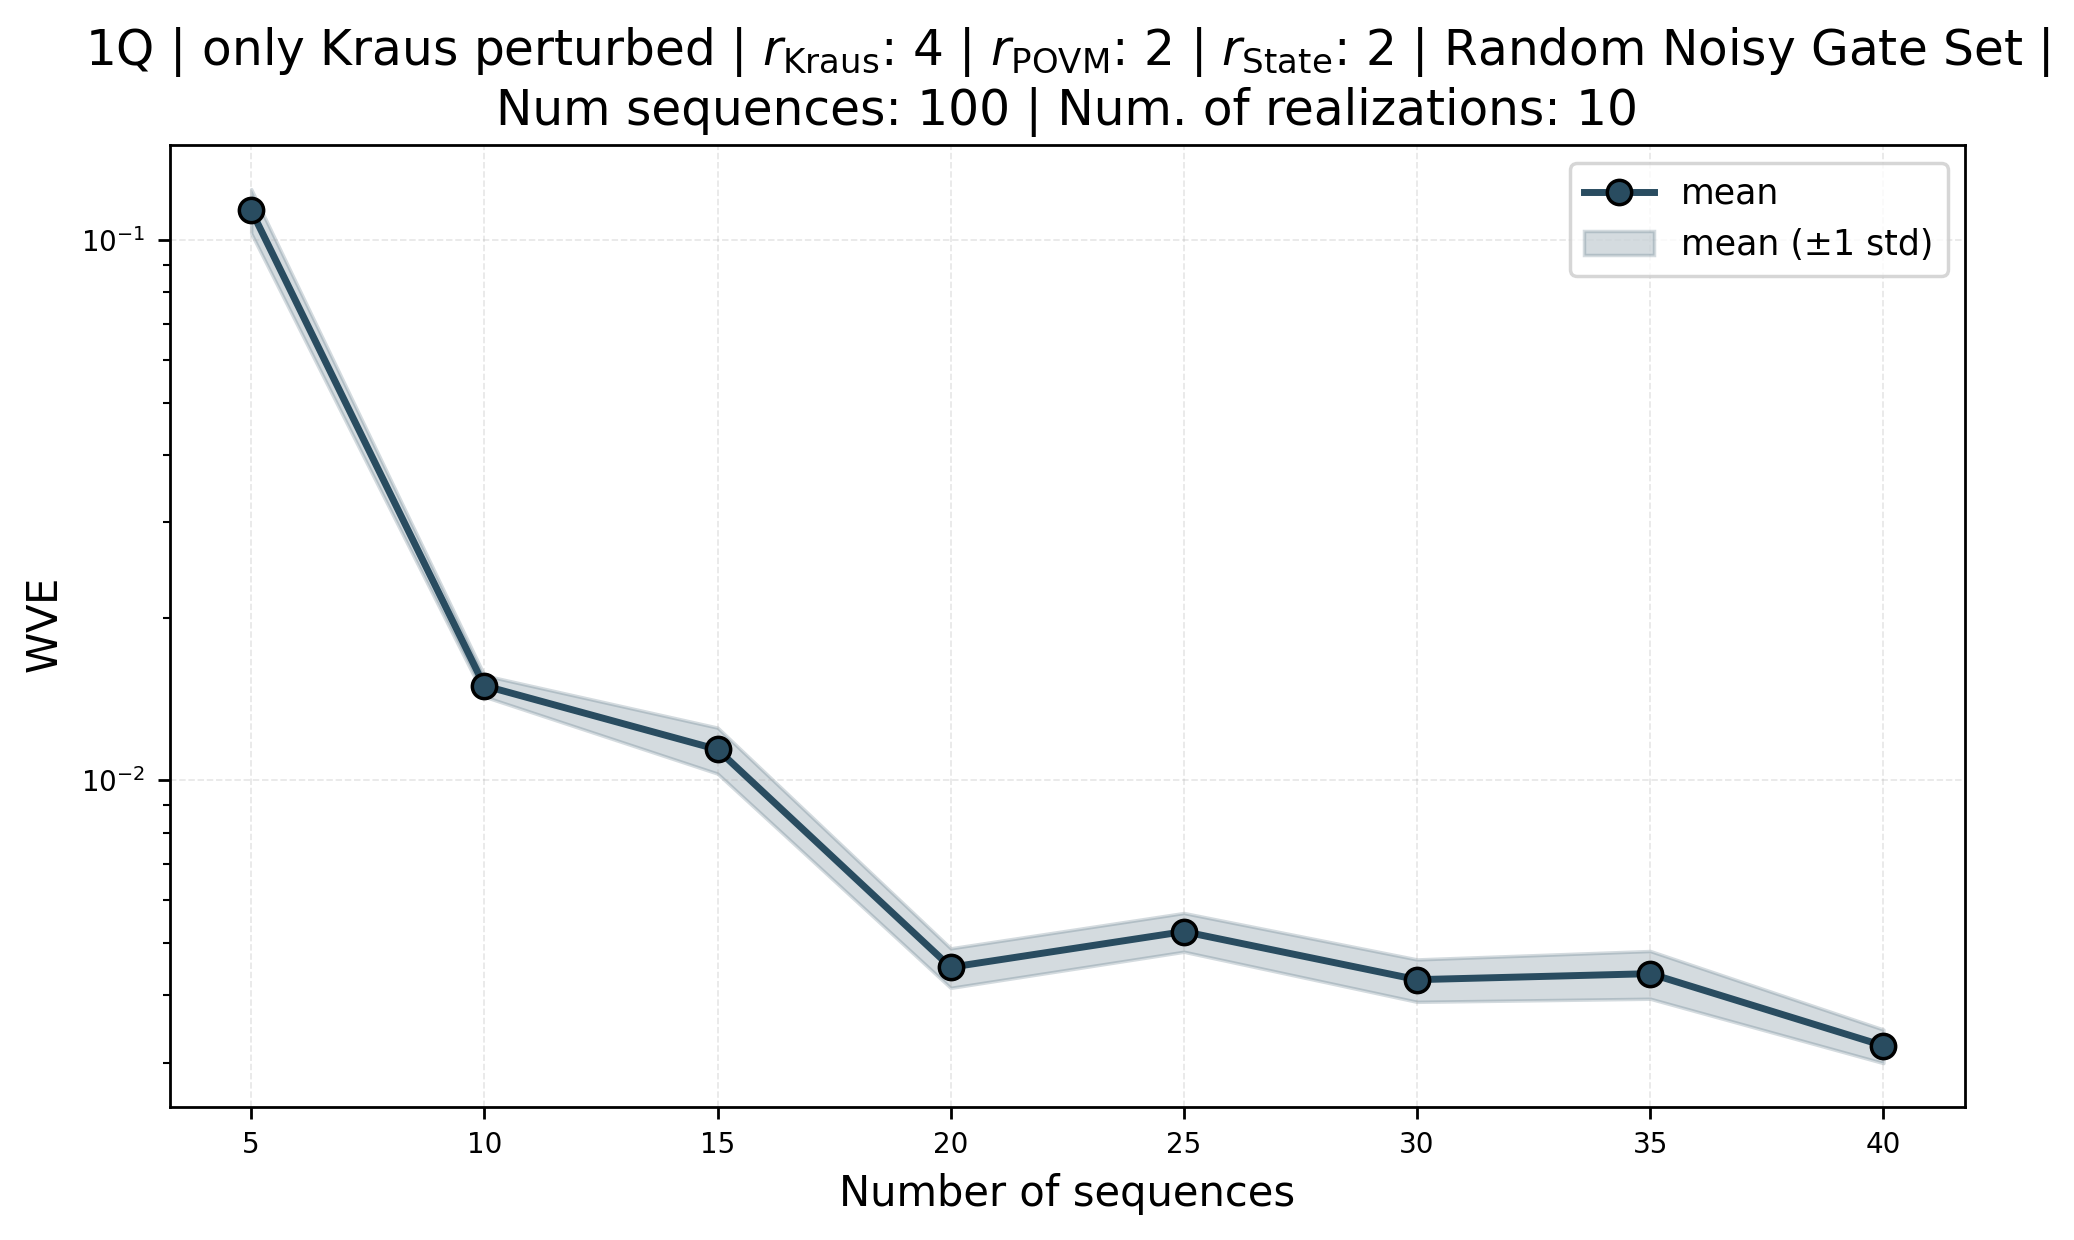

In [222]:
figure_wve_test_2 = plot_mean_std_vs_x(
    wve_all[1],
    title=title_100_seq + f" | Num. of realizations: {num_random_runs}",
    ylabel=r"$\text{WVE}$",
    use_log_scale="y",
)

In [264]:
from mGST.visualization import plot_many_mean_std_vs_x
from mGST.analysis import combine_error_results

In [ ]:
mean_wve_all = compute_avg_and_std_along_keys(list_of_errors=wve_all)
mean_wve_all

{'5': {'mean': Array(0.06709373, dtype=float64),
  'std': Array(0.03804794, dtype=float64)},
 '10': {'mean': Array(0.0117847, dtype=float64),
  'std': Array(0.00363456, dtype=float64)},
 '15': {'mean': Array(0.01150817, dtype=float64),
  'std': Array(0.00464774, dtype=float64)},
 '20': {'mean': Array(0.00599206, dtype=float64),
  'std': Array(0.00391432, dtype=float64)},
 '25': {'mean': Array(0.00549542, dtype=float64),
  'std': Array(0.00069585, dtype=float64)},
 '30': {'mean': Array(0.00495325, dtype=float64),
  'std': Array(0.00139775, dtype=float64)},
 '35': {'mean': Array(0.0040362, dtype=float64),
  'std': Array(0.0007558, dtype=float64)},
 '40': {'mean': Array(0.00350603, dtype=float64),
  'std': Array(0.00038489, dtype=float64)}}

In [238]:
mean_mve_all = compute_avg_and_std_along_keys(list_of_errors=mve_all)

In [252]:
title_realizations = rf"{num_qubits}Q | $r_\mathrm{{Kraus}}$: {kraus_rank} | $r_\mathrm{{POVM}}$: {povm_rank} | $r_\mathrm{{State}}$: {state_rank} | Random Noisy Gate Set |" + "\n" + f"| Num. of realizations: {realizations} | ({num_circuits_sampled} testing sequences)"

In [265]:
mve_combined = combine_error_results(mve_all, mve_medium)
wve_combined = combine_error_results(wve_all, wve_medium)

In [266]:
mean_wve_combined= compute_avg_and_std_along_keys(list_of_errors=wve_combined)
mean_mve_combined = compute_avg_and_std_along_keys(list_of_errors=mve_combined)

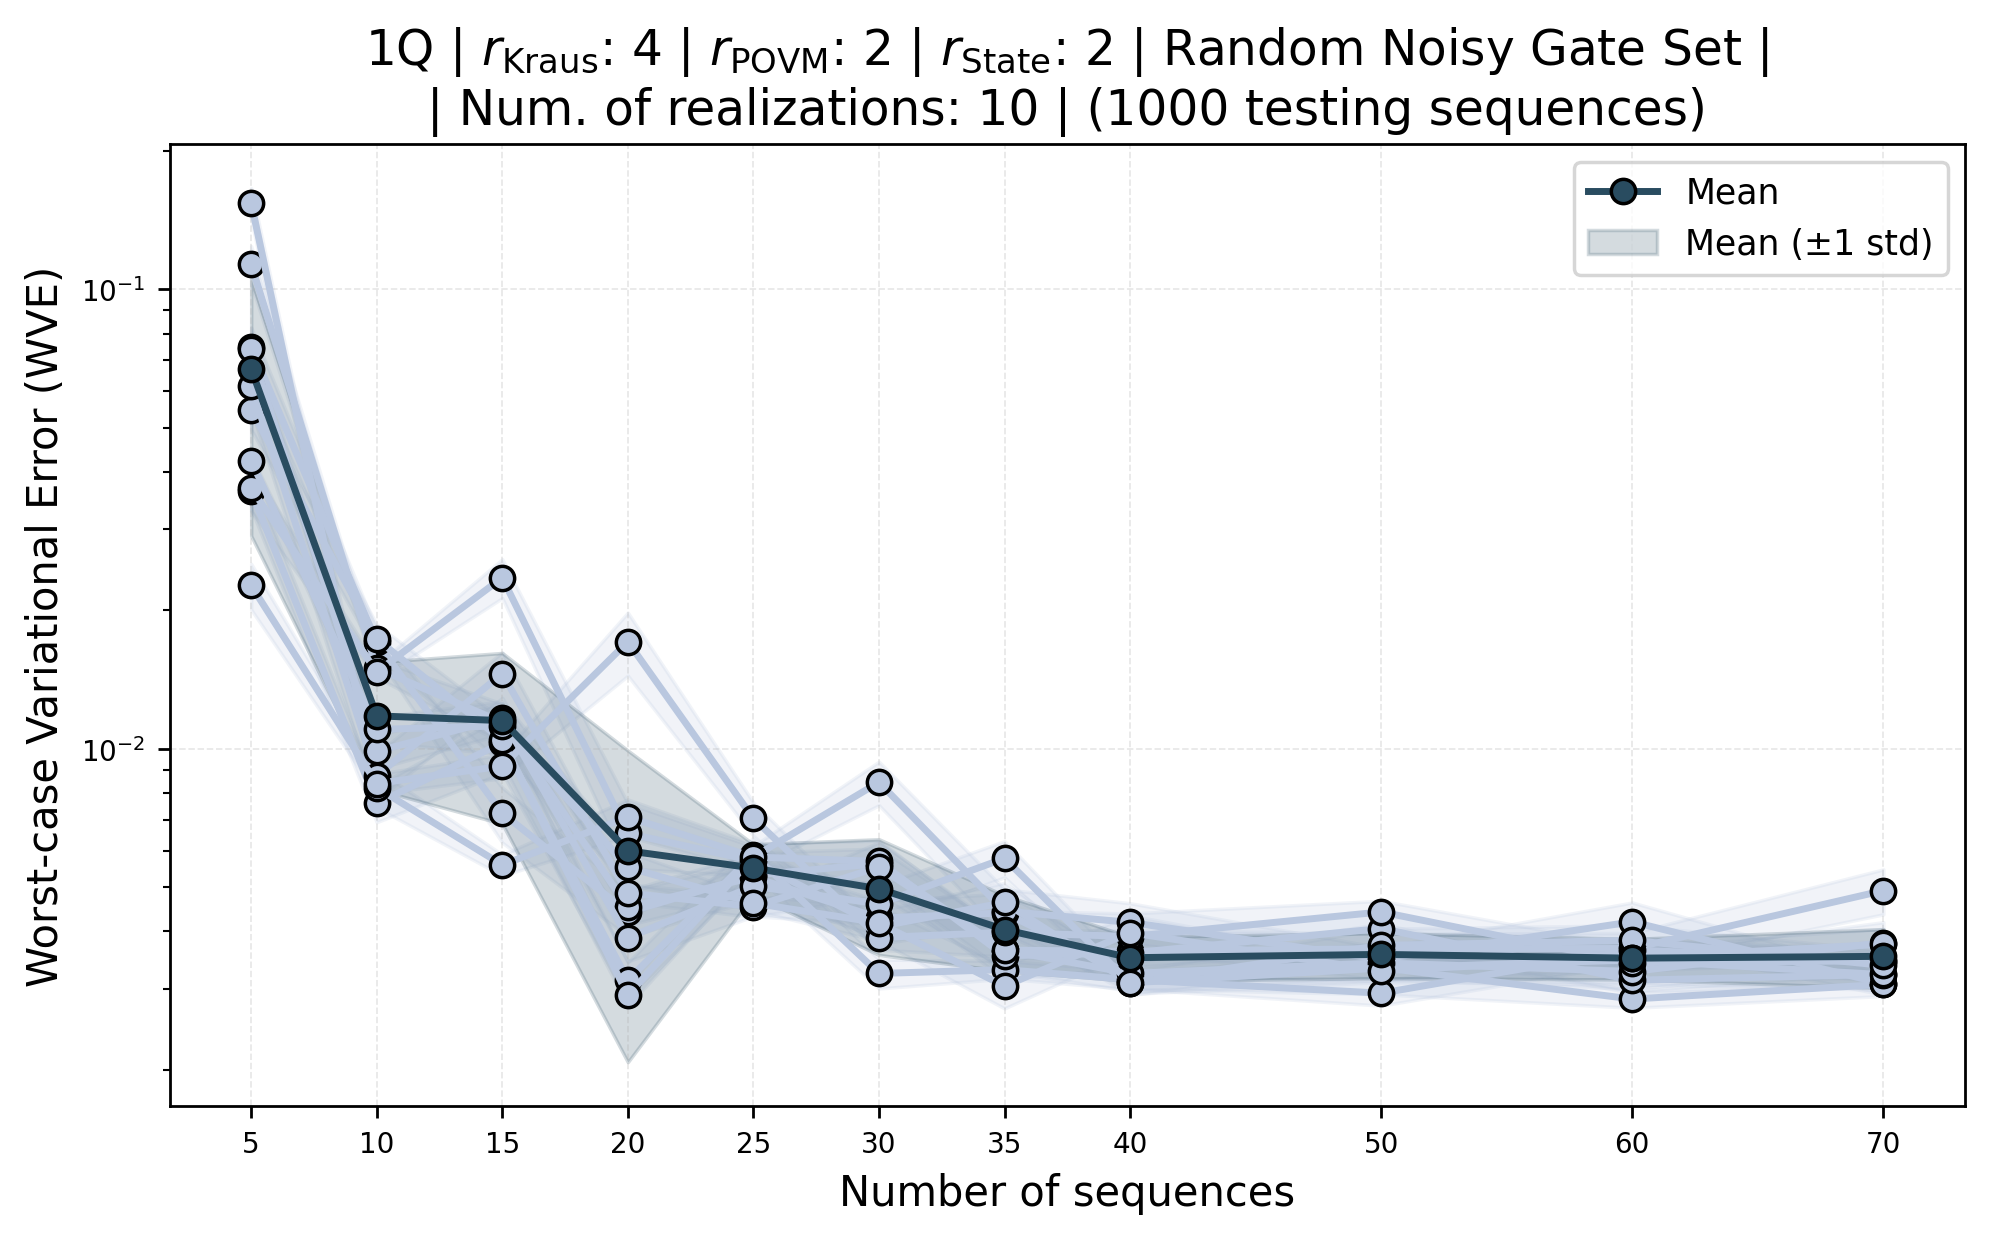

In [267]:
fig_all_wve  = plot_many_mean_std_vs_x(
    data=wve_combined,
    title=title_realizations,
    ylabel=f"Worst-case Variational Error (WVE)",
    use_log_scale="y",
    main_curve=mean_wve_combined,
    main_curve_label="Mean",
)

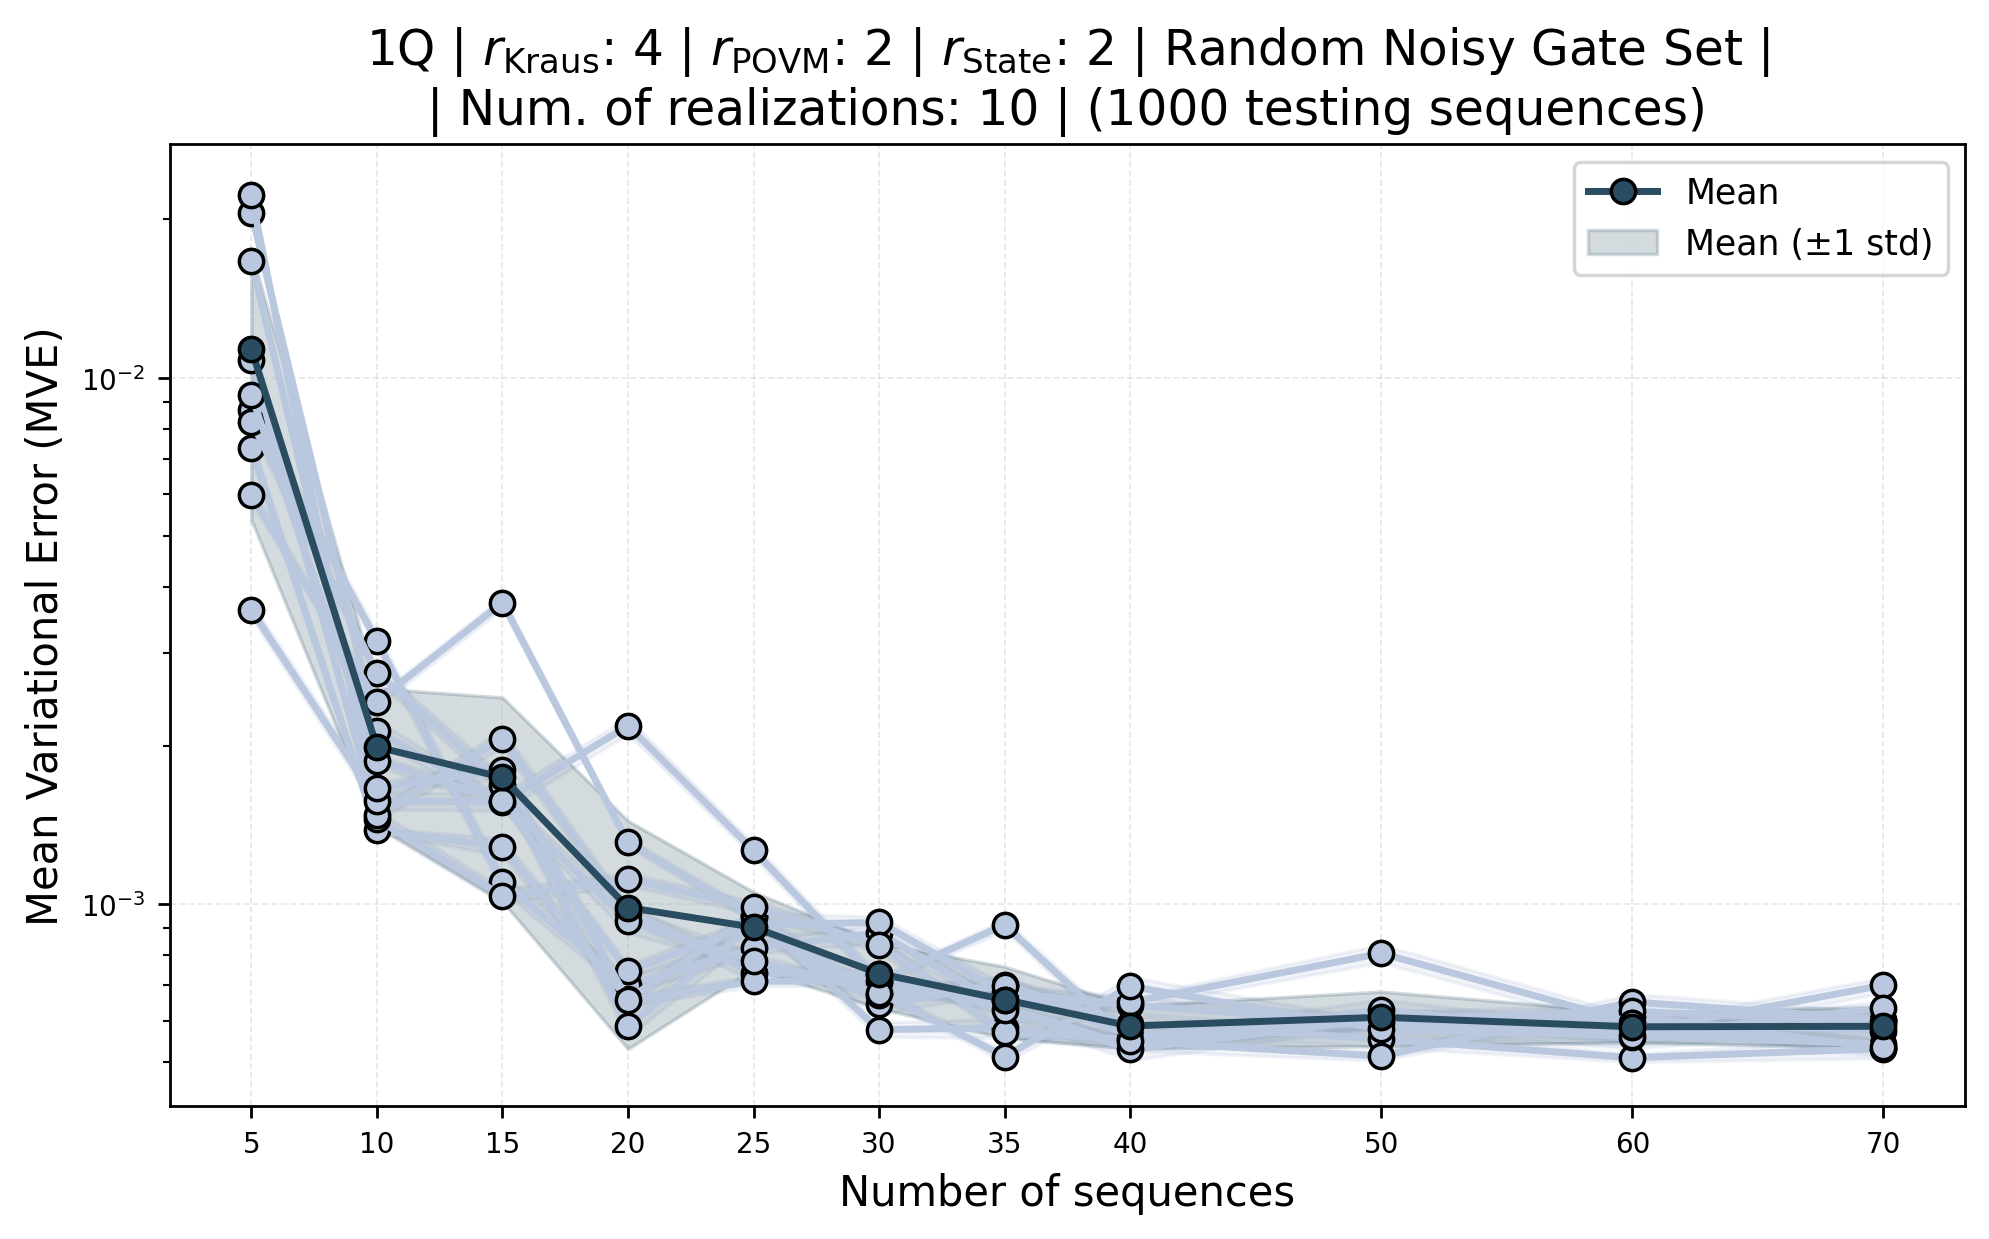

In [268]:
fig_all_mve  = plot_many_mean_std_vs_x(
    data=mve_combined,
    title=title_realizations,
    ylabel=f"Mean Variational Error (MVE)",
    use_log_scale="y",
    main_curve=mean_mve_combined,
    main_curve_label="Mean",
)

# Save combined experiments

In [269]:
import pickle

with open("optimization_results_small.pkl", "wb") as f:
    pickle.dump(optimization_results_all_realizations_exact_small, f)

with open("optimization_results_medium.pkl", "wb") as f:
    pickle.dump(optimization_results_all_realizations_exact_medium, f)


In [272]:
from mGST.analysis import to_json_serializable
import json

In [273]:
with open("mve_combined.json", "w") as f:
    json.dump(to_json_serializable(mve_combined), f, indent=2)

with open("wve_combined.json", "w") as f:
    json.dump(to_json_serializable(wve_combined), f, indent=2)

## convergence

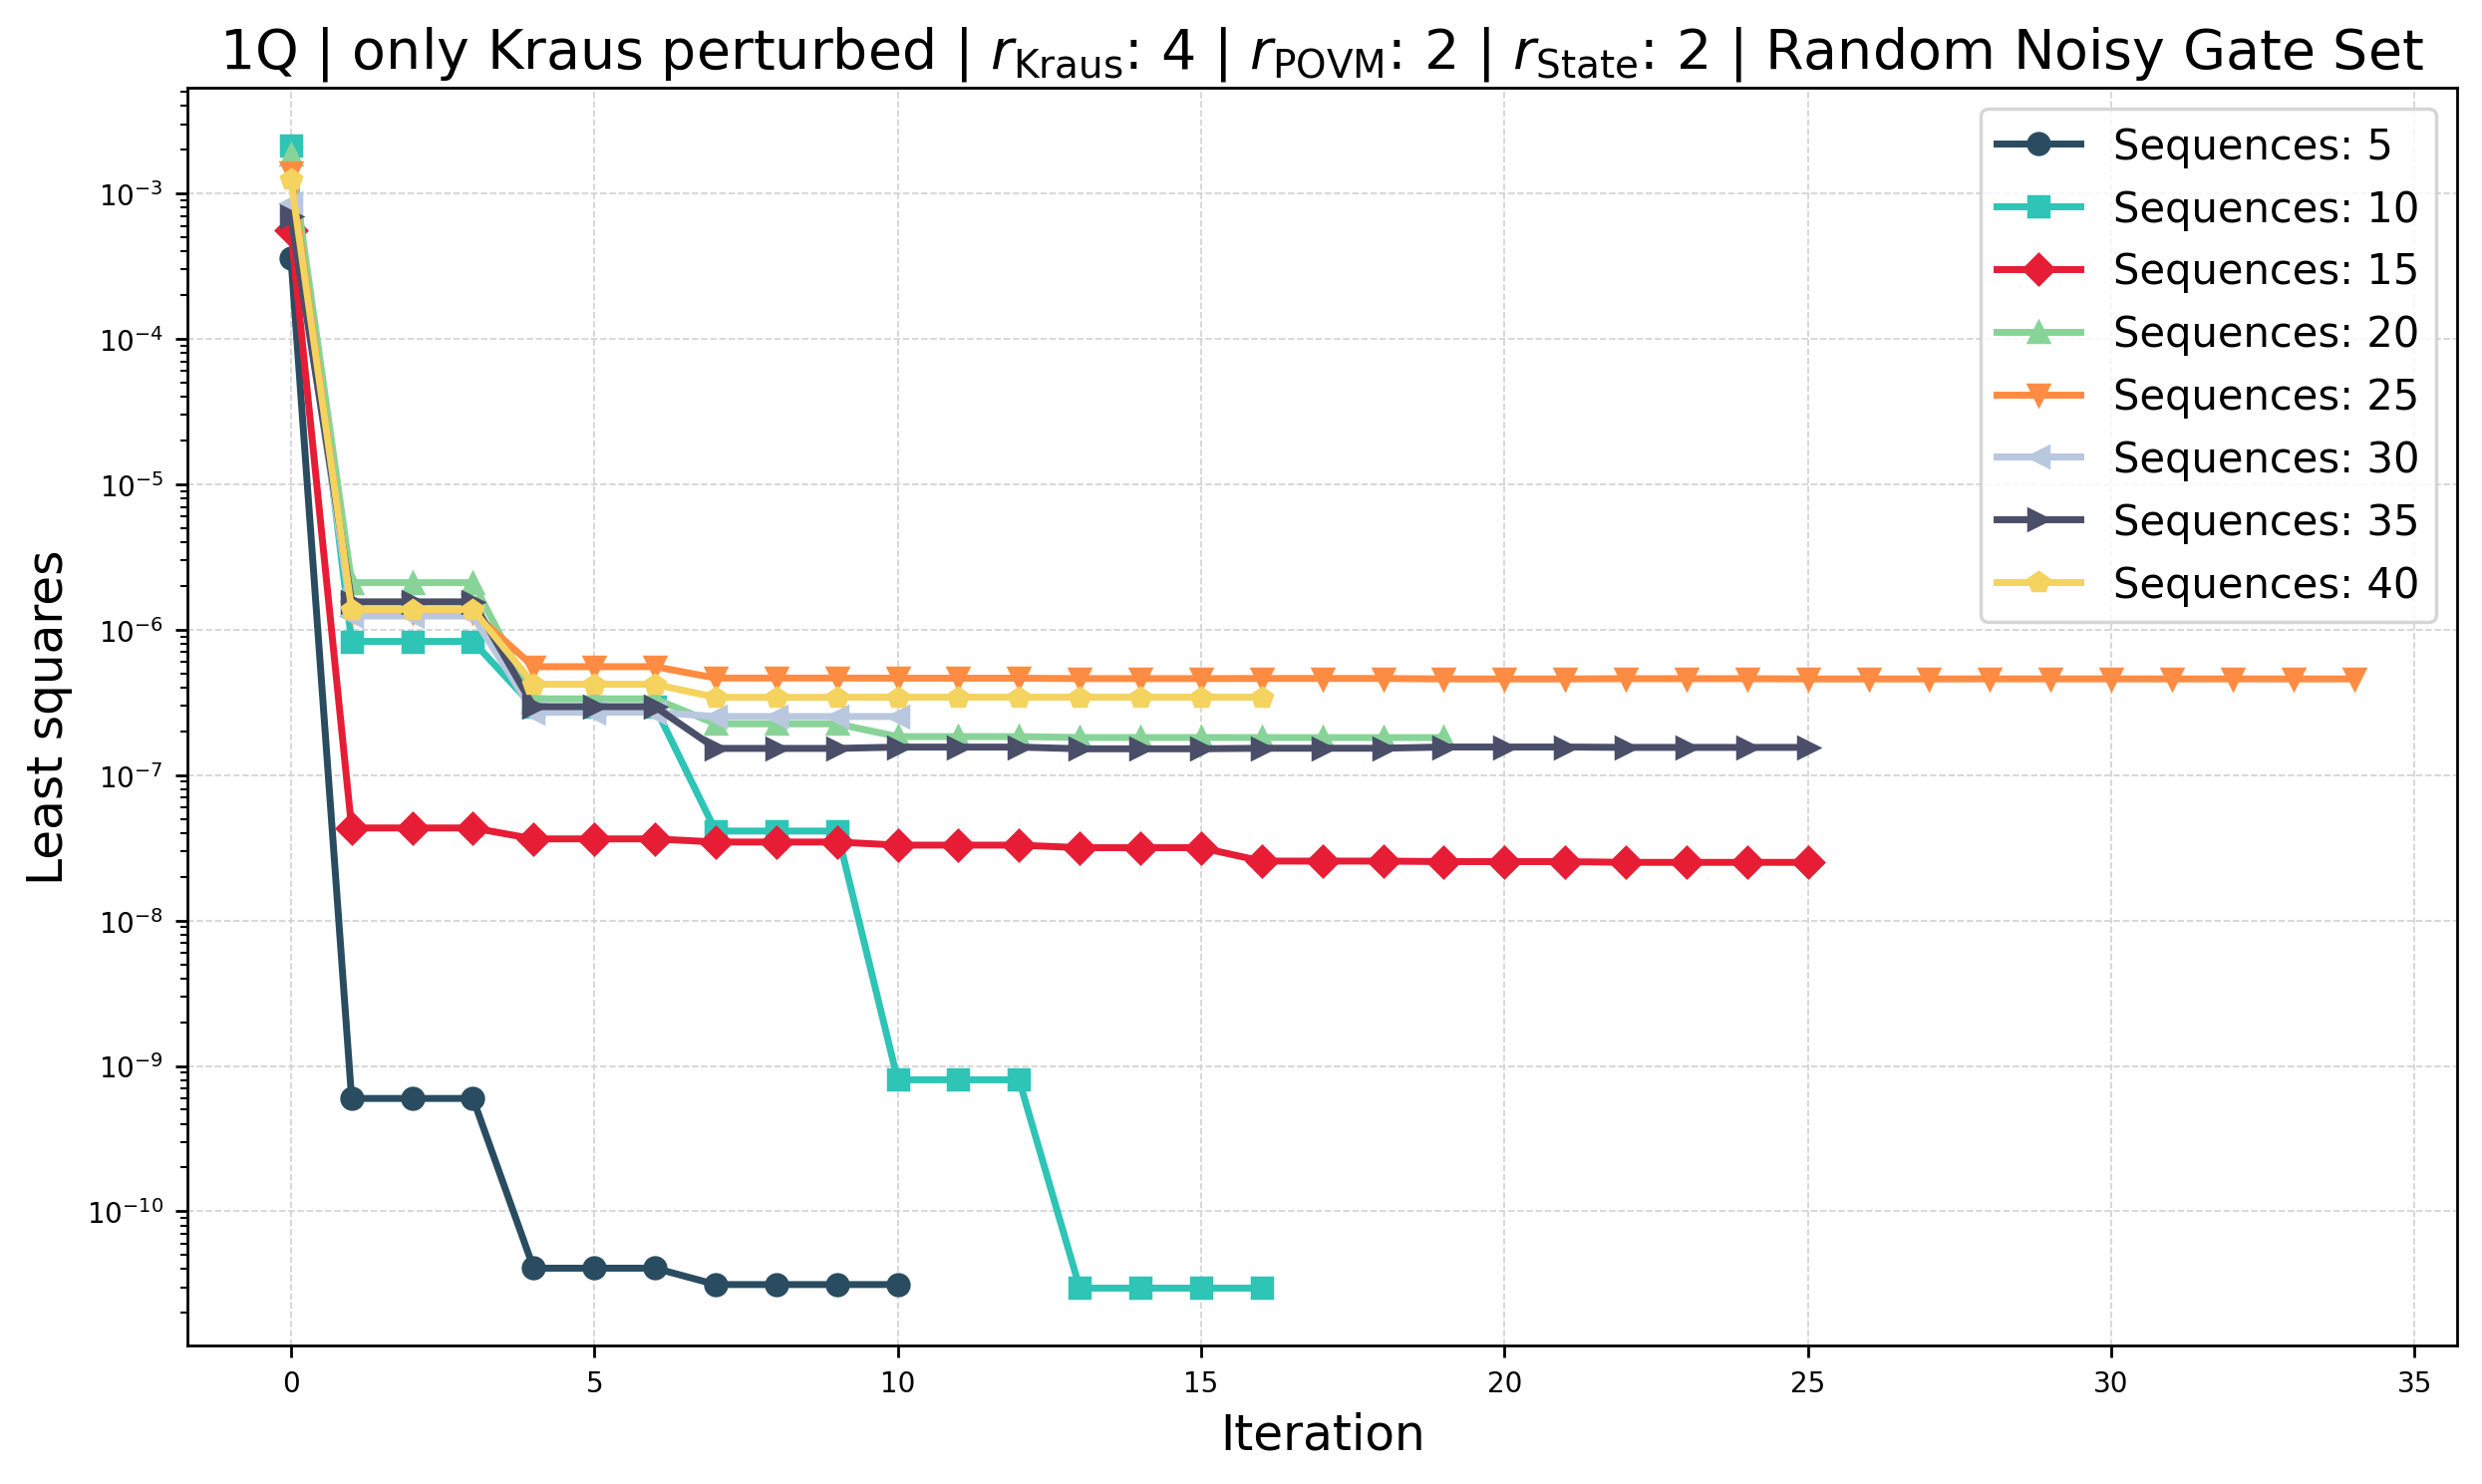

In [256]:
cost_fn_ls_vs_sequences_small = [res["cost_fn_history"]["least_squares"] for res in optimization_results_all_realizations_exact_small[0]]

labels_vs_sequences_small = [f"Sequences: {int(num_seq)}" for num_seq in num_sequences_list_small]

plot_cost_function(cost_fn_ls_vs_sequences_small, title=title_vs_sequences, labels=labels_vs_sequences_small, ylabel="Least squares")